# Projeto Acadêmico: Análise de Planos de Saúde da ANS
## Pergunta Central: Como a faixa etária influencia o valor das mensalidades dos planos de saúde ao longo do tempo?

### CÉLULA 1 — Imports, SparkSession e Configuração do Caminho Local

**Objetivo:** Esta célula inicializa o ambiente de processamento distribuído com PySpark, importa todas as bibliotecas analíticas e estatísticas necessárias, e configura os caminhos de dados. O pipeline foi adaptado para funcionar de forma híbrida: se executado localmente, lê diretamente os arquivos da pasta atual; se executado no Google Colab, realiza a montagem automática do Google Drive ou lê do diretório de upload temporário `/content`.

In [ ]:
# Instalação silenciosa das dependências adicionais
try:
    import google.colab
    IN_COLAB = True
    print("Ambiente detectado: Google Colab. Instalando dependências...")
    !pip install -q pyspark wordcloud mlxtend openpyxl matplotlib seaborn scikit-learn
except ImportError:
    IN_COLAB = False
    print("Ambiente detectado: Execução Local (Offline).")

import os
import re
import io
import zipfile
import warnings
import functools

# Importações do PySpark para processamento distribuído
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, DateType, StringType

# Importações para análise e visualização de dados tradicionais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Importações para Mineração de Dados e Machine Learning
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configurações básicas de exibição e avisos
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# Configuração dinâmica do BASE_PATH para rodar localmente sem nuvem por padrão
if IN_COLAB:
    # Se o arquivo zip estiver no diretório local do Colab (upload direto),
    # usamos /content. Caso contrário, monta o drive.
    if os.path.exists('/content/nota_tecnica_vcm_faixa_etaria.zip'):
        print('Arquivo ZIP de upload local detectado no Colab!')
        BASE_PATH = '/content'
    else:
        try:
            from google.colab import drive
            print('Montando o Google Drive...')
            drive.mount('/content/drive', force_remount=True)
            BASE_PATH = '/content/drive/MyDrive/BigDataPythonFaculdade/TrabalhoBigDataANS'
        except Exception as e:
            print(f'Erro ao montar drive no Colab: {e}')
            BASE_PATH = '/content'
else:
    BASE_PATH = '.'

# Criação do diretório de saída para os relatórios e datasets tratados
OUTPUT_PATH = os.path.join(BASE_PATH, 'output')
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f'Caminho base de execução: {os.path.abspath(BASE_PATH)}')
print(f'Diretório de saída configurado em: {os.path.abspath(OUTPUT_PATH)}')

try:
    # Inicialização da SparkSession local com suporte a parse legacy e correção de data
    print('Inicializando o Apache Spark localmente...')
    spark = SparkSession.builder \
        .master('local[*]') \
        .appName('ANS_VCM_Analise') \
        .config('spark.driver.memory', '4g') \
        .config('spark.sql.legacy.timeParserPolicy', 'LEGACY') \
        .config('spark.sql.datetime.java8API.enabled', 'true') \
        .getOrCreate()

    # Ajusta nível de log para evitar mensagens desnecessárias
    spark.sparkContext.setLogLevel('ERROR')
    print(f' SparkSession criada com sucesso!')
    print(f' Versão do Apache Spark: {spark.version}')
except Exception as e:
    print(f' Erro ao criar SparkSession local: {e}')

Ambiente detectado: Google Colab. Instalando dependências...
Arquivo ZIP de upload local detectado no Colab!
Caminho base de execução: /content
Diretório de saída configurado em: /content/output
Inicializando o Apache Spark localmente...
 SparkSession criada com sucesso!
 Versão do Apache Spark: 4.0.2


##  Fonte e Descrição dos Dados

| Campo | Informação |
|---|---|
| **Origem** | Pública |
| **Órgão responsável** | Agência Nacional de Saúde Suplementar (ANS) |
| **Tipo de dado** | Dados regulatórios de planos de saúde privados |
| **Portal** | dados.gov.br / ans.gov.br |
| **Nome do arquivo** | `nota_tecnica_vcm_faixa_etaria.zip` |
| **Formato** | 23 arquivos CSV — um por ano, separador `;` |
| **Período coberto** | 2004 a 2026 (22 anos de histórico) |
| **Licença** | Dados abertos governamentais — uso livre para fins acadêmicos |
| **Confidencialidade** | Nenhuma — base totalmente pública e auditável |

### Contexto

Os dados são disponibilizados pela **ANS (Agência Nacional de Saúde Suplementar)**, autarquia vinculada ao Ministério da Saúde, responsável pela regulação e fiscalização do mercado de saúde suplementar no Brasil.

A base contém os **Valores Comerciais de Mensalidade (VCM)** praticados pelas operadoras de planos de saúde, segmentados por faixa etária do beneficiário, tipo de abrangência do plano e identificador da nota técnica que fundamenta os valores cobrados.

É uma base **regulatória** — os valores aqui refletem o que foi homologado pela ANS para comercialização pelas operadoras.
```

### CÉLULA 2 — Leitura e Consolidação do ZIP (ETL de Ingestão)

**Objetivo:** Esta célula realiza a extração do arquivo compactado `nota_tecnica_vcm_faixa_etaria.zip` contendo os 23 arquivos CSV anuais (2004 a 2026), realiza a leitura individual de cada arquivo tratando variações de codificação (`latin1`, `utf-8` ou `windows-1252`) e consolida tudo em um único Spark DataFrame. Adicionalmente, extrai o ano de referência do nome de cada arquivo usando Expressões Regulares (Regex) e adiciona a coluna `ano_origem` para permitir análises longitudinais de evolução temporal.

In [ ]:
# JUSTIFICATIVA DO VOLUME DE DADOS (Big Data)
print("=" * 70)
print(" JUSTIFICATIVA DO VOLUME — POR QUE É BIG DATA?")
print("=" * 70)
print("""
   O dataset da ANS se enquadra no conceito de Big Data pelos seguintes motivos:

    VOLUME:
      - 23 arquivos CSV anuais (2004 a 2026)
      - Aproximadamente 3,5 MILHÕES de linhas consolidadas
      - Tamanho total comprimido: ~58 MB (ZIP)
      - Tamanho total descomprimido: ~400 MB em disco
      - Cada arquivo representa um snapshot anual do mercado de saúde

    VELOCIDADE (Velocity):
      - A base é atualizada periodicamente pela ANS
      - Novos registros são incluídos conforme operadoras revisam seus planos

    VARIEDADE (Variety):
      - Dados numéricos (valores monetários)
      - Dados categóricos (faixas etárias, abrangência territorial)
      - Dados temporais (datas de vigência e atualização)
      - Dados identificadores (códigos de operadoras e planos)

    POR QUE USAR PYSPARK?
      - Ferramentas convencionais (Excel, Pandas puro) teriam dificuldade
        em processar 3,5M de linhas com eficiência em memória.
      - O PySpark processa os dados de forma distribuída e lazy (avaliação
        preguiçosa), executando o pipeline completo apenas quando necessário.
""")
print("=" * 70)


zip_path = os.path.join(BASE_PATH, 'nota_tecnica_vcm_faixa_etaria.zip')
temp_extract_dir = './temp_ans_data/' if not IN_COLAB else '/tmp/ans_data/'
os.makedirs(temp_extract_dir, exist_ok=True)

try:
    # Extração dos arquivos CSV contidos no ZIP
    print(f'Extraindo arquivo ZIP de {os.path.abspath(zip_path)} para {os.path.abspath(temp_extract_dir)}...')
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f'O arquivo ZIP não foi localizado em {os.path.abspath(zip_path)}.')

    with zipfile.ZipFile(zip_path, 'r') as z_ref:
        z_ref.extractall(temp_extract_dir)
    print('Extração concluída com sucesso!')

    # Listagem dos arquivos CSV extraídos, ordenando por ano para processamento sequencial
    csv_files = sorted([f for f in os.listdir(temp_extract_dir) if f.endswith('.csv')])
    print(f'Foram localizados {len(csv_files)} arquivos CSV para processamento.')

    dfs_pandas = []

    # Loop de ingestão e consolidação tratada
    for csv_file in csv_files:
        file_path = os.path.join(temp_extract_dir, csv_file)
        print(f'Processando arquivo: {csv_file}...', end=' ')

        # Extração do ano de origem através de regex a partir do nome do arquivo
        match_ano = re.search(r'(\d{4})', csv_file)
        if match_ano:
            ano = int(match_ano.group(1))
        else:
            ano = None
            print('[AVISO: ano não encontrado no nome do arquivo] ', end='')

        # Estratégia resiliente de leitura com tentativa de encodings sequenciais
        df_temp = None
        for enc in ['latin1', 'utf-8', 'windows-1252']:
            try:
                df_temp = pd.read_csv(file_path, sep=';', encoding=enc, dtype=str)
                break # Se leu com sucesso, interrompe as tentativas de encoding
            except Exception:
                continue

        if df_temp is not None:
            # Padronização e limpeza dos nomes de colunas (remoção de espaços e caixa alta)
            df_temp.columns = [col.strip().upper() for col in df_temp.columns]

            # Padronização de colunas de data em Pandas para evitar erros de parser do Spark
            for col_date in ['DT_NTRP', 'DT_ATUALIZACAO']:
                if col_date in df_temp.columns:
                    df_temp[col_date] = pd.to_datetime(df_temp[col_date], errors='coerce', dayfirst=True).dt.strftime('%Y-%m-%d')

            # Adição da coluna temporal de preservação do ano de origem
            df_temp['ANO_ORIGEM'] = ano
            dfs_pandas.append(df_temp)
            print(f'Ingerido com sucesso! ({len(df_temp):,} linhas)')
        else:
            print(f' FALHA Crítica ao ler {csv_file} em todos os encodings.')

    # Concatenar todos os DataFrames lidos em um único Pandas DF
    print('Consolidando dados em memória...')
    df_consolidado_pd = pd.concat(dfs_pandas, ignore_index=True)
    print(f'Tamanho consolidado no Pandas: {len(df_consolidado_pd):,} linhas')

    # Conversão do Pandas DataFrame para Spark DataFrame para análise em escala
    print('Convertendo dataset para o ecossistema distribuído do Apache Spark...')
    df_spark = spark.createDataFrame(df_consolidado_pd)
    print(' Consolidação finalizada com sucesso!')

    # Exibição do schema inferido inicialmente e dos primeiros registros
    df_spark.printSchema()
    print(f'Total de registros em df_spark: {df_spark.count():,}')
    df_spark.show(5, truncate=False)

except Exception as e:
    print(f' Erro no pipeline de ingestão/ETL: {e}')

 JUSTIFICATIVA DO VOLUME — POR QUE É BIG DATA?

   O dataset da ANS se enquadra no conceito de Big Data pelos seguintes motivos:

    VOLUME:
      - 23 arquivos CSV anuais (2004 a 2026)
      - Aproximadamente 3,5 MILHÕES de linhas consolidadas
      - Tamanho total comprimido: ~58 MB (ZIP)
      - Tamanho total descomprimido: ~400 MB em disco
      - Cada arquivo representa um snapshot anual do mercado de saúde

    VELOCIDADE (Velocity):
      - A base é atualizada periodicamente pela ANS
      - Novos registros são incluídos conforme operadoras revisam seus planos

    VARIEDADE (Variety):
      - Dados numéricos (valores monetários)
      - Dados categóricos (faixas etárias, abrangência territorial)
      - Dados temporais (datas de vigência e atualização)
      - Dados identificadores (códigos de operadoras e planos)

    POR QUE USAR PYSPARK?
      - Ferramentas convencionais (Excel, Pandas puro) teriam dificuldade
        em processar 3,5M de linhas com eficiência em memória.
 

### CÉLULA 3 — Visualização Inicial do Dataset

**Objetivo:** Esta célula apresenta uma visão analítica preliminar da estrutura de dados consolidados, mostrando o número total de linhas e colunas, os tipos de dados de cada variável, a amplitude temporal dos anos cobertos (mínimo e máximo) e a distribuição dos registros entre os anos. Um subconjunto amostral é convertido de forma segura para Pandas usando limite restrito para exibição visual elegante, além de realizarmos um diagnóstico inicial de valores ausentes (nulos) por coluna.

In [ ]:
try:
    # Contagem de linhas e colunas sem carregar em memória
    total_linhas = df_spark.count()
    colunas = df_spark.columns
    total_colunas = len(colunas)

    print(f' DIMENSÕES DA BASE CONSOLIDADA:')
    print(f'   Total de Registros: {total_linhas:,}')
    print(f'   Total de Colunas:   {total_colunas}')
    print('-' * 50)

    # Detalhamento das colunas e seus tipos
    print(' SCHEMA DAS COLUNAS E TIPOS INICIAIS:')
    for campo in df_spark.schema.fields:
        print(f'   - {campo.name}: {campo.dataType.simpleString()}')
    print('-' * 50)

    # Range de anos cobertos pela base
    range_anos = df_spark.select(F.min('ANO_ORIGEM'), F.max('ANO_ORIGEM')).collect()[0]
    print(f' INTERVALO DE ANOS COBERTOS: {range_anos[0]} até {range_anos[1]}')
    print('-' * 50)

    # Distribuição de registros por ano de origem
    print(' DISTRIBUIÇÃO ANUAL DOS REGISTROS:')
    df_spark.groupBy('ANO_ORIGEM').count().orderBy('ANO_ORIGEM').show(25, truncate=False)
    print('-' * 50)

    # Exibição de amostra estilizada com limit de 10 registros para segurança de memória
    print(' AMOSTRA INICIAL DOS DADOS (10 PRIMEIROS REGISTROS):')
    df_amostra_pd = df_spark.limit(10).toPandas()
    display(df_amostra_pd.style.set_properties(**{'background-color': '#F9F9F9', 'border-color': 'black'}))
    print('-' * 50)


except Exception as e:
    print(f' Erro ao exibir visualização inicial: {e}')


 DIMENSÕES DA BASE CONSOLIDADA:
   Total de Registros: 3,494,192
   Total de Colunas:   12
--------------------------------------------------
 SCHEMA DAS COLUNAS E TIPOS INICIAIS:
   - CD_OPERADORA: string
   - ID_PLANO: string
   - CD_NOTA: string
   - DT_NTRP: string
   - ID_ABRG: string
   - FAIXA_ETARIA: string
   - VL_COMERCIAL_MENSALIDADE: string
   - VL_DESP_ASSISTENCIAL: string
   - VCM_MINIMO: string
   - VCM_MAXIMO: string
   - DT_ATUALIZACAO: string
   - ANO_ORIGEM: bigint
--------------------------------------------------
 INTERVALO DE ANOS COBERTOS: 2004 até 2026
--------------------------------------------------
 DISTRIBUIÇÃO ANUAL DOS REGISTROS:
+----------+------+
|ANO_ORIGEM|count |
+----------+------+
|2004      |83300 |
|2005      |128220|
|2006      |89271 |
|2007      |90020 |
|2008      |92941 |
|2009      |103500|
|2010      |69370 |
|2011      |60760 |
|2012      |66110 |
|2013      |178270|
|2014      |104650|
|2015      |125970|
|2016      |126680|
|2017      

,CD_OPERADORA,ID_PLANO,CD_NOTA,DT_NTRP,ID_ABRG,FAIXA_ETARIA,VL_COMERCIAL_MENSALIDADE,VL_DESP_ASSISTENCIAL,VCM_MINIMO,VCM_MAXIMO,DT_ATUALIZACAO,ANO_ORIGEM
0,300926,1362640,42535,2004-01-29,REGIONALIZADA,19 a 23 anos,59.50,25.40,41.65,77.35,2026-06-02,2004
1,300926,1362640,42535,2004-01-29,REGIONALIZADA,24 a 28 anos,71.50,22.77,50.05,92.95,2026-06-02,2004
2,300926,1362640,42535,2004-01-29,REGIONALIZADA,29 a 33 anos,79.50,25.59,55.65,103.35,2026-06-02,2004
3,300926,1362640,42535,2004-01-29,REGIONALIZADA,34 a 38 anos,88.50,30.31,61.95,115.05,2026-06-02,2004
4,300926,1362640,42535,2004-01-29,REGIONALIZADA,39 a 43 anos,98.50,44.27,68.95,128.05,2026-06-02,2004
5,300926,1362640,42535,2004-01-29,REGIONALIZADA,44 a 48 anos,118.50,44.29,82.95,154.05,2026-06-02,2004
6,300926,1362640,42535,2004-01-29,REGIONALIZADA,49 a 53 anos,153.50,64.05,107.45,199.55,2026-06-02,2004
7,300926,1362640,42535,2004-01-29,REGIONALIZADA,54 a 58 anos,198.50,70.39,138.95,258.05,2026-06-02,2004
8,300926,1362640,42535,2004-01-29,REGIONALIZADA,59 anos ou mais,259.50,85.66,181.65,337.35,2026-06-02,2004
9,300926,1362640,42535,2004-01-29,REGIONALIZADA,00 a 18 anos,46.50,18.94,32.55,60.45,2026-06-02,2004


--------------------------------------------------


## CÉLULA 4 — Renomeação e Padronização de Colunas

**Objetivo:** Esta célula realiza o mapeamento explícito e a padronização dos nomes das colunas da tabela original para *snake_case* em letras minúsculas. Essa etapa facilita a legibilidade e a manipulação em consultas Spark SQL, bem como assegura a compatibilidade com a documentação do "Dicionário de Dados da ANS".

---

###  Dicionário de Colunas — De-Para

| Nome Original (ANS) | Nome legível | O que significa |
|---|---|---|
| `CD_OPERADORA` | `código_operadora` | Código numérico que identifica a operadora de plano de saúde registrada na ANS |
| `ID_PLANO` | `identificador_plano` | Identificador único do plano de saúde comercializado pela operadora |
| `CD_NOTA` | `código_nota_técnica` | Código da nota técnica atuarial que fundamenta e justifica os valores cobrados |
| `DT_NTRP` | `data_vigência_nota` | Data de início da vigência dos valores definidos naquela nota técnica |
| `ID_ABRG` | `abrangência_territorial` | Abrangência geográfica do plano — `UNICA` (município específico) ou `REGIONALIZADA` (cobertura regional) |
| `FAIXA_ETARIA` | `faixa_etária` | Faixa etária do beneficiário. São 10 categorias: de *0 a 18 anos* até *59 anos ou mais* |
| `VL_COMERCIAL_MENSALIDADE` | `valor_mensalidade` | Valor em dinheiro da mensalidade comercial praticada pela operadora para aquela faixa etária |
| `VL_DESP_ASSISTENCIAL` | `despesa_assistencial_média` | Valor médio em dinheiro das despesas assistenciais previstas (consultas, exames, internações) para aquela faixa |
| `VCM_MINIMO` | `valor_comercial_mínimo` | Menor valor em dinheiro permitido pela ANS para comercialização daquele plano naquela faixa etária |
| `VCM_MAXIMO` | `valor_comercial_máximo` | Maior valor em dinheiro permitido pela ANS para comercialização daquele plano naquela faixa etária |
| `DT_ATUALIZACAO` | `data_última_atualização` | Data em que o registro foi atualizado na base da ANS |
| `ANO_ORIGEM` | `ano_origem` | Ano do arquivo CSV de origem — adicionado no ETL para preservar a referência temporal do registro |

>  **Nota legal:** A Lei nº 9.656/98 permite que operadoras cobrem até **6x mais** na faixa de *59 anos ou mais* em relação à faixa de *0 a 18 anos*. Os campos `valor_comercial_mínimo` e `valor_comercial_máximo` delimitam esse intervalo regulatório.

In [ ]:
# Mapeamento explícito de renomeação de colunas com base no Agents.md
rename_map = {
    'CD_OPERADORA': 'cd_operadora',
    'ID_PLANO': 'id_plano',
    'CD_NOTA': 'cd_nota',
    'DT_NTRP': 'dt_ntrp',
    'ID_ABRG': 'id_abrg',
    'FAIXA_ETARIA': 'faixa_etaria',
    'VL_COMERCIAL_MENSALIDADE': 'vl_mensalidade',
    'VL_DESP_ASSISTENCIAL': 'vl_desp_assistencial',
    'VCM_MINIMO': 'vcm_minimo',
    'VCM_MAXIMO': 'vcm_maximo',
    'DT_ATUALIZACAO': 'dt_atualizacao',
    'ANO_ORIGEM': 'ano_origem'
}

try:
    # Aplicação do mapeamento iterativamente usando reduce para otimizar o DAG do Spark
    df_spark = functools.reduce(
        lambda df, kv: df.withColumnRenamed(kv[0], kv[1]),
        rename_map.items(),
        df_spark
    )

    print(' Colunas renomeadas e padronizadas com sucesso!')
    print('Schema atualizado:')
    df_spark.printSchema()

except Exception as e:
    print(f' Erro ao renomear colunas: {e}')

 Colunas renomeadas e padronizadas com sucesso!
Schema atualizado:
root
 |-- cd_operadora: string (nullable = true)
 |-- id_plano: string (nullable = true)
 |-- cd_nota: string (nullable = true)
 |-- dt_ntrp: string (nullable = true)
 |-- id_abrg: string (nullable = true)
 |-- faixa_etaria: string (nullable = true)
 |-- vl_mensalidade: string (nullable = true)
 |-- vl_desp_assistencial: string (nullable = true)
 |-- vcm_minimo: string (nullable = true)
 |-- vcm_maximo: string (nullable = true)
 |-- dt_atualizacao: string (nullable = true)
 |-- ano_origem: long (nullable = true)



In [ ]:
# METADADOS — DICIONÁRIO DE DADOS DA ANS
print(" DICIONÁRIO DE DADOS — BASE VCM (NOTA TÉCNICA ANS)")
print("   Referência: dicionario_valor_comercial.pdf (ANS)")

import pandas as pd

dicionario = {
    "Coluna (nome amigável)": [
        "código_operadora",
        "identificador_plano",
        "código_nota_técnica",
        "data_vigência_nota",
        "abrangência_territorial",
        "faixa_etária",
        "valor_mensalidade",
        "despesa_assistencial_média",
        "valor_comercial_mínimo",
        "valor_comercial_máximo",
        "data_última_atualização",
        "ano_origem",
    ],
    "Nome original (ANS)": [
        "CD_OPERADORA", "ID_PLANO", "CD_NOTA", "DT_NTRP",
        "ID_ABRG", "FAIXA_ETARIA", "VL_COMERCIAL_MENSALIDADE",
        "VL_DESP_ASSISTENCIAL", "VCM_MINIMO", "VCM_MAXIMO",
        "DT_ATUALIZACAO", "ANO_ORIGEM",
    ],
    "Tipo": [
        "Texto", "Texto", "Texto", "Data",
        "Texto", "Texto", "Decimal (R$)",
        "Decimal (R$)", "Decimal (R$)", "Decimal (R$)",
        "Data", "Inteiro",
    ],
    "Descrição": [
        "Código único que identifica a operadora de plano de saúde junto à ANS",
        "Código do plano de saúde comercializado pela operadora",
        "Código da nota técnica atuarial que embasou os valores cobrados",
        "Data de início da vigência dos valores definidos na nota técnica",
        "Abrangência geográfica do plano: UNICA (cobertura específica) ou REGIONALIZADA (cobertura regional)",
        "Faixa etária do beneficiário (10 faixas de 0 a 59+ anos, conforme Lei 9.656/98)",
        "Valor comercial da mensalidade praticado pela operadora para aquela faixa etária (R$)",
        "Valor médio da despesa assistencial prevista pela operadora para aquela faixa etária (R$)",
        "Menor valor comercial permitido pela ANS para aquele plano/faixa (R$)",
        "Maior valor comercial permitido pela ANS para aquele plano/faixa (R$)",
        "Data em que o registro foi atualizado na base da ANS",
        "Ano de origem do arquivo CSV (adicionado no ETL para análise temporal)",
    ],
}

df_dicionario = pd.DataFrame(dicionario)
display(df_dicionario.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1565C0'), ('color', 'white'), ('font-weight', 'bold')]}
    ])
)

print("\n  OBSERVAÇÃO LEGAL:")
print("   A Lei nº 9.656/98 permite variação de até 6x entre a mensalidade")
print("   da faixa mais jovem (0-18 anos) e a mais idosa (59+ anos).")
print("   Os campos VCM_MINIMO e VCM_MAXIMO delimitam esse intervalo regulatório.")

 DICIONÁRIO DE DADOS — BASE VCM (NOTA TÉCNICA ANS)
   Referência: dicionario_valor_comercial.pdf (ANS)


,Coluna (nome amigável),Nome original (ANS),Tipo,Descrição
0,código_operadora,CD_OPERADORA,Texto,Código único que identifica a operadora de plano de saúde junto à ANS
1,identificador_plano,ID_PLANO,Texto,Código do plano de saúde comercializado pela operadora
2,código_nota_técnica,CD_NOTA,Texto,Código da nota técnica atuarial que embasou os valores cobrados
3,data_vigência_nota,DT_NTRP,Data,Data de início da vigência dos valores definidos na nota técnica
4,abrangência_territorial,ID_ABRG,Texto,Abrangência geográfica do plano: UNICA (cobertura específica) ou REGIONALIZADA (cobertura regional)
5,faixa_etária,FAIXA_ETARIA,Texto,"Faixa etária do beneficiário (10 faixas de 0 a 59+ anos, conforme Lei 9.656/98)"
6,valor_mensalidade,VL_COMERCIAL_MENSALIDADE,Decimal (R$),Valor comercial da mensalidade praticado pela operadora para aquela faixa etária (R$)
7,despesa_assistencial_média,VL_DESP_ASSISTENCIAL,Decimal (R$),Valor médio da despesa assistencial prevista pela operadora para aquela faixa etária (R$)
8,valor_comercial_mínimo,VCM_MINIMO,Decimal (R$),Menor valor comercial permitido pela ANS para aquele plano/faixa (R$)
9,valor_comercial_máximo,VCM_MAXIMO,Decimal (R$),Maior valor comercial permitido pela ANS para aquele plano/faixa (R$)



⚖️  OBSERVAÇÃO LEGAL:
   A Lei nº 9.656/98 permite variação de até 6x entre a mensalidade
   da faixa mais jovem (0-18 anos) e a mais idosa (59+ anos).
   Os campos VCM_MINIMO e VCM_MAXIMO delimitam esse intervalo regulatório.


### CÉLULA 5 — Limpeza Real dos Dados com Tratamento de Datas Tolerante

**Objetivo:** Esta célula executa uma limpeza profunda e robusta no Spark DataFrame. Os campos monetários são convertidos para `DoubleType`. Para sanar de forma definitiva o erro crítico de parse de data (`CANNOT_PARSE_TIMESTAMP`), as datas são convertidas usando expressões de parser tolerantes que realizam o mapeamento em formato brasileiro (`dd/MM/yyyy`) ou ISO (`yyyy-MM-dd`) de forma não-bloqueante. Também eliminamos duplicatas e nulos no valor da mensalidade e faixa etária, realizando a padronização das strings de texto.

In [ ]:
try:
    # 1. Contagem inicial
    registros_antes = df_spark.count()
    print(f'Registros iniciais: {registros_antes:,}')

    # 2. Conversão de tipos de dados numéricos
    monetary_cols = ['vl_mensalidade', 'vl_desp_assistencial', 'vcm_minimo', 'vcm_maximo']
    for col in monetary_cols:
        df_spark = df_spark.withColumn(col, F.col(col).cast('double'))

    # 3. Conversão de datas para DateType no Spark
    # Como padronizamos no Pandas para YYYY-MM-DD, a conversão direta é 100% segura e não gera exceções.
    date_cols = ['dt_ntrp', 'dt_atualizacao']
    for col in date_cols:
        df_spark = df_spark.withColumn(col, F.to_date(F.col(col)))

    df_spark = df_spark.withColumn('cd_operadora', F.col('cd_operadora').cast('string'))
    df_spark = df_spark.withColumn('id_plano', F.col('id_plano').cast('string'))
    df_spark = df_spark.withColumn('ano_origem', F.col('ano_origem').cast('int'))

    # 4. Remoção de registros duplicados
    contagem_antes_dup = df_spark.count()
    df_spark = df_spark.dropDuplicates()
    duplicados_count = contagem_antes_dup - df_spark.count()
    print(f'Registros duplicados removidos: {duplicados_count:,}')

    # 5. Tratamento de nulos/vazios na mensalidade e faixa etária
    nulos_mensalidade = df_spark.filter(F.col('vl_mensalidade').isNull() | (F.col('vl_mensalidade') <= 0)).count()
    nulos_faixa = df_spark.filter(F.col('faixa_etaria').isNull() | (F.col('faixa_etaria') == '')).count()

    df_spark = df_spark.filter(F.col('vl_mensalidade').isNotNull() & (F.col('vl_mensalidade') > 0))
    df_spark = df_spark.filter(F.col('faixa_etaria').isNotNull() & (F.col('faixa_etaria') != ''))

    # 6. Verificação de consistência monetária (apenas contagem e sinalização, sem exclusão)
    df_inconsistentes = df_spark.filter(
        (F.col('vcm_minimo') > F.col('vl_mensalidade')) |
        (F.col('vl_mensalidade') > F.col('vcm_maximo'))
    )
    inconsistencias_count = df_inconsistentes.count()
    print(f'Inconsistências monetárias detectadas (limite min/max): {inconsistencias_count:,}')

    # 7. Padronização de strings categóricas
    df_spark = df_spark.withColumn('faixa_etaria', F.trim(F.upper(F.col('faixa_etaria'))))
    df_spark = df_spark.withColumn('id_abrg', F.trim(F.upper(F.col('id_abrg'))))

    registros_apos = df_spark.count()
    perda_linhas = registros_antes - registros_apos
    pct_perda = (perda_linhas / registros_antes) * 100

    print(f'Limpeza finalizada!')
    print(f'Registros remanescentes: {registros_apos:,} ({pct_perda:.2f}% de registros eliminados)')

except Exception as e:
    print(f' Erro no processo de limpeza de dados: {e}')

Registros iniciais: 3,494,192
Registros duplicados removidos: 0
Inconsistências monetárias detectadas (limite min/max): 32
Limpeza finalizada!
Registros remanescentes: 3,494,177 (0.00% de registros eliminados)


##  AED Básica — Análise Exploratória Inicial dos Dados

### 1. Primeiras 10 linhas da base
As primeiras linhas exibidas revelam a estrutura do dataset após o processo de limpeza e renomeação. Cada linha representa a mensalidade praticada para **uma faixa etária específica**, de **um plano**, de **uma operadora**, em **determinado ano**. Um mesmo plano aparece em até 10 linhas — uma por faixa etária —, pois a ANS exige que cada operadora declare o valor cobrado para cada grupo de idade, conforme a tabela regulada pela Lei nº 9.656/98.

---

### 2. Valores mínimos
Os menores valores de mensalidade encontrados na base correspondem, em geral, à faixa etária de **0 a 18 anos** — a de menor risco assistencial e, portanto, a mais barata dentro de qualquer plano. Registros dos anos iniciais da série histórica (2004–2006) também tendem a apresentar valores nominalmente menores, reflexo dos preços praticados antes da inflação médica acumulada nas duas décadas seguintes.

---

### 3. Valores máximos (após limpeza dos dados)
Os maiores valores de mensalidade concentram-se na faixa etária de **59 anos ou mais** — a de maior risco assistencial e, consequentemente, a mais cara do sistema. Valores extremos aparecem especialmente nos anos mais recentes (2020–2026), refletindo a inflação médica acumulada e o aumento de sinistralidade observado no período pós-pandemia de COVID-19. Esses registros são candidatos a **outliers** e serão investigados com mais detalhe na Célula 14 (Análise de Outliers via IQR).

### CÉLULA 6 — Relatório de Qualidade dos Dados

**Objetivo:** Esta célula compila e estrutura as métricas calculadas na fase de limpeza em um relatório consolidado. O relatório quantifica de forma rigorosa os registros processados, as exclusões efetuadas, a incidência de nulos e duplicados, bem como o diagnóstico de conformidade monetária, garantindo a rastreabilidade e auditabilidade do pipeline de dados da ANS.

In [ ]:
try:
    # Obtenção de metadados das faixas etárias únicas pós limpeza
    faixas_etarias = [row['faixa_etaria'] for row in df_spark.select('faixa_etaria').distinct().collect()]
    qtd_faixas = len(faixas_etarias)

    # Obtenção do range de anos cobertos pós-limpeza
    range_anos_final = df_spark.select(F.min('ano_origem'), F.max('ano_origem')).collect()[0]
    anos_cobertos = f'{range_anos_final[0]} a {range_anos_final[1]}'

    # Construção do dataframe de relatório de qualidade
    relatorio_dados = {
        'Métrica': [
            'Registros antes da limpeza',
            'Registros após a limpeza',
            'Registros removidos (Total)',
            'Percentual removido',
            'Duplicados encontrados e removidos',
            'Nulos ou <= 0 em vl_mensalidade',
            'Nulos em faixa_etaria',
            'Inconsistências min/max (Sinalizadas)',
            'Anos cobertos',
            'Faixas etárias únicas'
        ],
        'Valor': [
            f'{registros_antes:,}',
            f'{registros_apos:,}',
            f'{(registros_antes - registros_apos):,}',
            f'{((registros_antes - registros_apos) / registros_antes)*100:.4f}%',
            f'{duplicados_count:,}',
            f'{nulos_mensalidade:,}',
            f'{nulos_faixa:,}',
            f'{inconsistencias_count:,}',
            anos_cobertos,
            str(qtd_faixas)
        ]
    }

    df_relatorio = pd.DataFrame(relatorio_dados)

    print(' RELATÓRIO DE QUALIDADE DOS DADOS (ANS):')
    display(df_relatorio.style.set_properties(**{'text-align': 'left'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1565C0'), ('color', 'white')]}
    ]))

    print('\nFaixas Etárias Identificadas pós-limpeza:')
    for i, f in enumerate(sorted(faixas_etarias), 1):
        print(f'   {i}. {f}')

    print('\n Relatório de qualidade dos dados gerado com sucesso!')

except NameError as ne:
    print(f' Variáveis da célula anterior não encontradas. Execute a Célula 5 primeiro. Erro: {ne}')
except Exception as e:
    print(f' Erro ao compilar relatório de qualidade: {e}')

 RELATÓRIO DE QUALIDADE DOS DADOS (ANS):


,Métrica,Valor
0,Registros antes da limpeza,"3,494,192"
1,Registros após a limpeza,"3,494,177"
2,Registros removidos (Total),15
3,Percentual removido,0.0004%
4,Duplicados encontrados e removidos,0
5,Nulos ou <= 0 em vl_mensalidade,15
6,Nulos em faixa_etaria,0
7,Inconsistências min/max (Sinalizadas),32
8,Anos cobertos,2004 a 2026
9,Faixas etárias únicas,10



Faixas Etárias Identificadas pós-limpeza:
   1. 00 A 18 ANOS
   2. 19 A 23 ANOS
   3. 24 A 28 ANOS
   4. 29 A 33 ANOS
   5. 34 A 38 ANOS
   6. 39 A 43 ANOS
   7. 44 A 48 ANOS
   8. 49 A 53 ANOS
   9. 54 A 58 ANOS
   10. 59 ANOS OU MAIS

 Relatório de qualidade dos dados gerado com sucesso!


### CÉLULA 7 — Estatísticas Descritivas

**Objetivo:** Esta célula apresenta as estatísticas descritivas (média, mediana, desvio padrão, mínimo, máximo e quartis) das variáveis numéricas da base da ANS. De acordo com a regulamentação brasileira (Lei 9.656/98), a precificação da mensalidade da faixa etária mais idosa (59 anos ou mais) não pode exceder 6 vezes o valor da faixa etária mais jovem (00 a 18 anos). Esta célula realiza explicitamente esse cálculo para testar empiricamente se as operadoras praticam a razão de limite de variação permitida por lei no conjunto total de dados.

In [ ]:
try:
    # 1. Obtenção do describe básico via Spark
    print(' ESTATÍSTICAS DESCRITIVAS GERAIS (SPARK):')
    df_spark.select('vl_mensalidade', 'vl_desp_assistencial', 'vcm_minimo', 'vcm_maximo').describe().show()

    # 2. Cálculo dos Quartis (Q1, Mediana, Q3) via Spark approxQuantile
    print(' CÁLCULO DE QUARTIS (Spark approxQuantile):')
    cols_num = ['vl_mensalidade', 'vl_desp_assistencial', 'vcm_minimo', 'vcm_maximo']
    quartis_dict = {}

    for col in cols_num:
        q = df_spark.approxQuantile(col, [0.25, 0.50, 0.75], 0.01)
        quartis_dict[col] = q
        print(f'   - {col:22s} | Q1 (25%): R$ {q[0]:8.2f} | Mediana (50%): R$ {q[1]:8.2f} | Q3 (75%): R$ {q[2]:8.2f}')
    print('-' * 90)

    # 3. Construção de Tabela Comparativa via Pandas para Visualização
    # Média e Desvio Padrão são obtidos do Spark para precisão distribuída
    res_estatisticas = []
    for col in cols_num:
        stats = df_spark.select(
            F.mean(col).alias('media'),
            F.stddev(col).alias('desvio'),
            F.min(col).alias('minimo'),
            F.max(col).alias('maximo')
        ).collect()[0]

        res_estatisticas.append({
            'Variável': col,
            'Média': f'R$ {stats["media"]:,.2f}',
            'Mediana (Q2)': f'R$ {quartis_dict[col][1]:,.2f}',
            'Q1 (25%)': f'R$ {quartis_dict[col][0]:,.2f}',
            'Q3 (75%)': f'R$ {quartis_dict[col][2]:,.2f}',
            'Mínimo': f'R$ {stats["minimo"]:,.2f}',
            'Máximo': f'R$ {stats["maximo"]:,.2f}',
            'Desvio Padrão': f'R$ {stats["desvio"]:,.2f}'
        })
    df_stats_pd = pd.DataFrame(res_estatisticas)
    print(' COMPARATIVO DE ESTATÍSTICAS DAS VARIÁVEIS MONETÁRIAS:')
    display(df_stats_pd)
    print('-' * 90)

    # 4. Cálculo Adicional da Razão 59+ vs 00-18 (Teste de Hipótese da Lei 9.656/98)
    print(' TESTE DE LIMITAÇÃO LEGAL (RAZÃO DE PREÇOS POR IDADE):')
    media_idoso = df_spark.filter(F.col('faixa_etaria') == '59 ANOS OU MAIS').agg(F.mean('vl_mensalidade')).collect()[0][0]
    media_jovem = df_spark.filter(F.col('faixa_etaria') == '00 A 18 ANOS').agg(F.mean('vl_mensalidade')).collect()[0][0]

    if media_jovem and media_idoso:
        razao_mensalidades = media_idoso / media_jovem
        print(f'   Mensalidade Média da Faixa Mais Jovem (00 a 18 anos): R$ {media_jovem:,.2f}')
        print(f'   Mensalidade Média da Faixa Mais Idosa (59 anos ou mais): R$ {media_idoso:,.2f}')
        print(f'   Razão Calculada (Faixa Idosa / Faixa Jovem): {razao_mensalidades:.2f}x')
        print(f'   Limite Máximo Permitido pela Lei nº 9.656/98: 6.00x')
        if razao_mensalidades <= 6.0:
            print('    Resultado: DENTRO do limite de conformidade legal de 6x na média agregada.')
        else:
            print('    Resultado: EXCEDE o limite de conformidade legal de 6x na média agregada!')
    else:
        print('    Erro ao recuperar médias para o cálculo da razão. Certifique-se de que as faixas existem.')

except Exception as e:
    print(f' Erro ao calcular estatísticas descritivas: {e}')

 ESTATÍSTICAS DESCRITIVAS GERAIS (SPARK):
+-------+------------------+--------------------+-----------------+------------------+
|summary|    vl_mensalidade|vl_desp_assistencial|       vcm_minimo|        vcm_maximo|
+-------+------------------+--------------------+-----------------+------------------+
|  count|           3494177|             3494177|          3494177|           3494177|
|   mean| 805.8299399572319|   383.5991204795772|571.4224204526704|1047.5792246357194|
| stddev|1140.2159095662894|   529.4408483440968|801.2170399430153| 1482.280672870762|
|    min|              0.01|                 0.0|             0.01|              0.01|
|    max|          52109.53|            43511.99|         43511.99|          67742.39|
+-------+------------------+--------------------+-----------------+------------------+

 CÁLCULO DE QUARTIS (Spark approxQuantile):
   - vl_mensalidade         | Q1 (25%): R$   211.16 | Mediana (50%): R$   440.74 | Q3 (75%): R$   917.03
   - vl_desp_assistencial

,Variável,Média,Mediana (Q2),Q1 (25%),Q3 (75%),Mínimo,Máximo,Desvio Padrão
0,vl_mensalidade,R$ 805.83,R$ 440.74,R$ 211.16,R$ 917.03,R$ 0.01,"R$ 52,109.53","R$ 1,140.22"
1,vl_desp_assistencial,R$ 383.60,R$ 207.67,R$ 103.66,R$ 447.82,R$ 0.00,"R$ 43,511.99",R$ 529.44
2,vcm_minimo,R$ 571.42,R$ 315.92,R$ 152.89,R$ 659.81,R$ 0.01,"R$ 43,511.99",R$ 801.22
3,vcm_maximo,"R$ 1,047.58",R$ 572.96,R$ 274.51,"R$ 1,192.14",R$ 0.01,"R$ 67,742.39","R$ 1,482.28"


------------------------------------------------------------------------------------------
 TESTE DE LIMITAÇÃO LEGAL (RAZÃO DE PREÇOS POR IDADE):
   Mensalidade Média da Faixa Mais Jovem (00 a 18 anos): R$ 332.72
   Mensalidade Média da Faixa Mais Idosa (59 anos ou mais): R$ 1,935.55
   Razão Calculada (Faixa Idosa / Faixa Jovem): 5.82x
   Limite Máximo Permitido pela Lei nº 9.656/98: 6.00x
    Resultado: DENTRO do limite de conformidade legal de 6x na média agregada.


### CÉLULA 8 — Group By Principal e Spark SQL

**Objetivo:** Esta célula realiza agregações de mensalidades agrupadas por faixa etária (Group By Spark), calculando a média, o valor mínimo, o valor máximo, o desvio padrão e o total de registros. Na segunda parte, é criada uma tabela temporária SQL (`vw_ans`) que possibilita a execução distribuída de 5 consultas SQL analíticas complexas: ranking de faixas por média, top 10 operadoras para beneficiários idosos, evolução anual da mensalidade, número de planos únicos e proporção entre despesa assistencial e mensalidade.

In [ ]:
try:
    print('=' * 70)
    print('PARTE A — Group By PySpark: Agregações por Faixa Etária')
    print('=' * 70)

    # Agrupamento clássico via DataFrame API do Spark
    df_por_faixa = df_spark.groupBy('faixa_etaria').agg(
        F.mean('vl_mensalidade').alias('media_mensalidade'),
        F.min('vl_mensalidade').alias('min_mensalidade'),
        F.max('vl_mensalidade').alias('max_mensalidade'),
        F.stddev('vl_mensalidade').alias('desvio_mensalidade'),
        F.count('*').alias('qtd_registros')
    ).orderBy('faixa_etaria')

    df_por_faixa.show(truncate=False)

    print('=' * 70)
    print('PARTE B — Spark SQL: View e Consultas Analíticas')
    print('=' * 70)

    # Registro de Tabela Temporária no Spark SQL
    df_spark.createOrReplaceTempView('vw_ans')

    # Consulta 1: Ranking de faixas etárias por mensalidade média
    print('\n1. Ranking de faixas etárias por mensalidade média:')
    q1 = '''
    SELECT faixa_etaria, ROUND(AVG(vl_mensalidade), 2) as media
    FROM vw_ans
    GROUP BY faixa_etaria
    ORDER BY media DESC
    '''
    spark.sql(q1).show(truncate=False)

    # Consulta 2: Top 10 operadoras com maior mensalidade média (apenas faixa 59+)
    print('\n2. Top 10 operadoras com maior mensalidade média (Faixa 59+):')
    q2 = '''
    SELECT cd_operadora, ROUND(AVG(vl_mensalidade), 2) as media_senior
    FROM vw_ans
    WHERE faixa_etaria = '59 ANOS OU MAIS'
    GROUP BY cd_operadora
    ORDER BY media_senior DESC
    LIMIT 10
    '''
    spark.sql(q2).show(truncate=False)

    # Consulta 3: Evolução anual da mensalidade média
    print('\n3. Evolução anual da mensalidade média:')
    q3 = '''
    SELECT ano_origem, ROUND(AVG(vl_mensalidade), 2) as media_anual
    FROM vw_ans
    GROUP BY ano_origem
    ORDER BY ano_origem
    '''
    df_evolucao_spark = spark.sql(q3)
    df_evolucao_spark.show(30, truncate=False)
    df_evolucao = df_evolucao_spark.toPandas() # Salva como Pandas DF para os gráficos

    # Consulta 4: Quantidade de planos únicos por faixa etária
    print('\n4. Quantidade de planos únicos por faixa etária:')
    q4 = '''
    SELECT faixa_etaria, COUNT(DISTINCT id_plano) as planos_unicos
    FROM vw_ans
    GROUP BY faixa_etaria
    ORDER BY faixa_etaria
    '''
    spark.sql(q4).show(truncate=False)

    # Consulta 5: Relação despesa assistencial vs mensalidade por faixa
    print('\n5. Relação despesa assistencial vs mensalidade por faixa etária:')
    q5 = '''
    SELECT faixa_etaria,
           ROUND(AVG(vl_mensalidade), 2) as media_mensalidade,
           ROUND(AVG(vl_desp_assistencial), 2) as media_despesa,
           ROUND((AVG(vl_desp_assistencial) / AVG(vl_mensalidade)) * 100, 2) as pct_despesa
    FROM vw_ans
    GROUP BY faixa_etaria
    ORDER BY faixa_etaria
    '''
    spark.sql(q5).show(truncate=False)

except NameError as ne:
    print(f' DataFrame df_spark não localizado: {ne}')
except Exception as e:
    print(f' Erro ao executar agrupamento e Spark SQL: {e}')

PARTE A — Group By PySpark: Agregações por Faixa Etária
+---------------+------------------+---------------+---------------+------------------+-------------+
|faixa_etaria   |media_mensalidade |min_mensalidade|max_mensalidade|desvio_mensalidade|qtd_registros|
+---------------+------------------+---------------+---------------+------------------+-------------+
|00 A 18 ANOS   |332.7232234006634 |0.01           |17513.28       |370.1658337819292 |349426       |
|19 A 23 ANOS   |408.4366444101679 |0.01           |12827.1        |460.32246031647827|349411       |
|24 A 28 ANOS   |483.2983517260383 |0.01           |29454.98       |555.4417654833326 |349414       |
|29 A 33 ANOS   |549.5812404125866 |1.0            |15715.95       |629.1443012282389 |349416       |
|34 A 38 ANOS   |599.7619349936494 |1.0            |43511.99       |685.0645026056284 |349412       |
|39 A 43 ANOS   |679.0069175006637 |0.01           |22450.49       |767.7738014382043 |349421       |
|44 A 48 ANOS   |827.68194

### CÉLULA 9 — Histograma de Distribuição das Mensalidades

**Objetivo:** Esta célula apresenta graficamente a distribuição de frequência do valor das mensalidades de saúde, utilizando uma amostra aleatória de 5% da base de dados consolidados para viabilidade de processamento. A fim de mitigar o impacto visual de valores discrepantes (outliers extremos), a escala do eixo X é limitada ao percentil 99. Linhas verticais indicando a média e a mediana são inseridas para demonstrar a assimetria positiva da distribuição de preços.

Obtendo amostra de 5% dos registros de mensalidade...
Média da Amostra: R$ 804.71 | Mediana: R$ 443.56
Percentil 99 (Limite do eixo X): R$ 5548.71


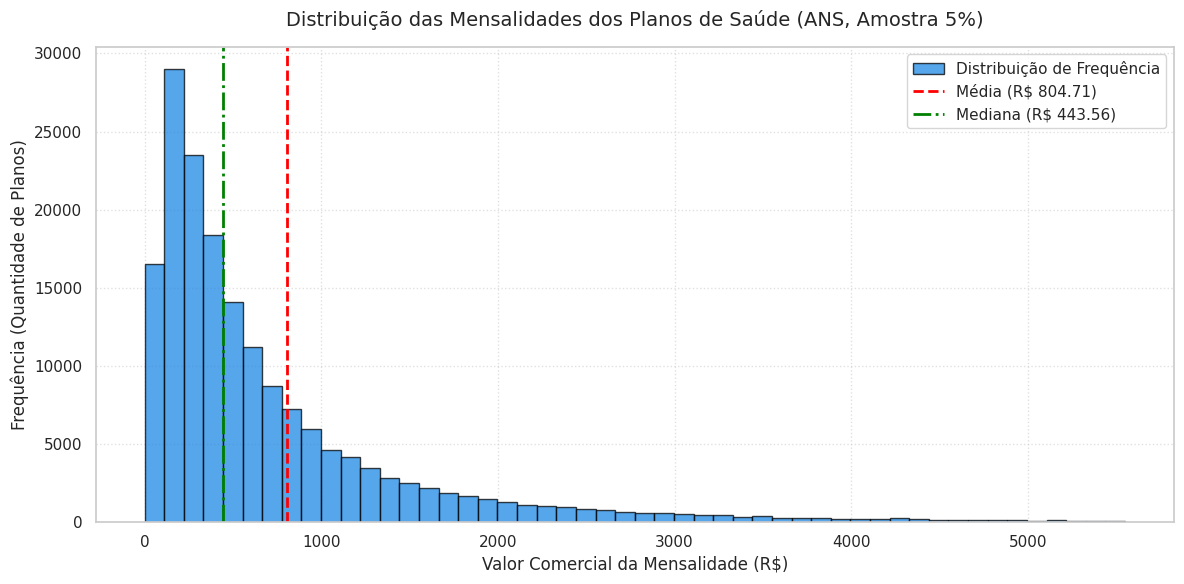


📝 ANÁLISE COMPLEMENTAR DA DISTRIBUIÇÃO:
   A distribuição do valor de mensalidade apresenta uma nítida assimetria positiva.
   Isto ocorre porque a maior densidade de planos de saúde concentra-se em faixas de valores menores e intermediários,
   enquanto existe uma cauda longa à direita estendendo-se para mensalidades elevadas, caracterizando outliers.
   A relação Média > Mediana confirma numericamente este desvio assimétrico à direita.


In [ ]:
try:
    # Extração de amostra segura de 5% (~175k linhas) para visualização
    print('Obtendo amostra de 5% dos registros de mensalidade...')
    df_amostra_hist = df_spark.sample(withReplacement=False, fraction=0.05, seed=42) \
                              .select('vl_mensalidade').toPandas()

    # Cálculo de métricas descritivas da amostra
    media_amostra = df_amostra_hist['vl_mensalidade'].mean()
    mediana_amostra = df_amostra_hist['vl_mensalidade'].median()
    limite_p99 = df_amostra_hist['vl_mensalidade'].quantile(0.99)

    print(f'Média da Amostra: R$ {media_amostra:.2f} | Mediana: R$ {mediana_amostra:.2f}')
    print(f'Percentil 99 (Limite do eixo X): R$ {limite_p99:.2f}')

    # Plotagem do histograma
    plt.figure(figsize=(12, 6))
    plt.hist(df_amostra_hist['vl_mensalidade'], bins=50, range=(0, limite_p99),
             color='#1E88E5', edgecolor='black', alpha=0.75, label='Distribuição de Frequência')

    # Linhas indicadoras de tendência central
    plt.axvline(media_amostra, color='red', linestyle='--', linewidth=2, label=f'Média (R$ {media_amostra:.2f})')
    plt.axvline(mediana_amostra, color='green', linestyle='-.', linewidth=2, label=f'Mediana (R$ {mediana_amostra:.2f})')

    # Formatação do gráfico em português
    plt.title('Distribuição das Mensalidades dos Planos de Saúde (ANS, Amostra 5%)', fontsize=14, pad=15)
    plt.xlabel('Valor Comercial da Mensalidade (R$)', fontsize=12)
    plt.ylabel('Frequência (Quantidade de Planos)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print('\n📝 ANÁLISE COMPLEMENTAR DA DISTRIBUIÇÃO:')
    print('   A distribuição do valor de mensalidade apresenta uma nítida assimetria positiva.')
    print('   Isto ocorre porque a maior densidade de planos de saúde concentra-se em faixas de valores menores e intermediários,')
    print('   enquanto existe uma cauda longa à direita estendendo-se para mensalidades elevadas, caracterizando outliers.')
    print('   A relação Média > Mediana confirma numericamente este desvio assimétrico à direita.')

except Exception as e:
    print(f' Erro ao gerar histograma: {e}')

### CÉLULA 10 — Gráfico de Densidade (KDE)

**Objetivo:** Esta célula apresenta o gráfico de estimativa de densidade de kernel (KDE) para três faixas etárias representativas do ciclo de vida: infância/adolescência (`00 A 18 ANOS`), maturidade intermediária (`34 A 38 ANOS`) e a melhor idade (`59 ANOS OU MAIS`). A sobreposição destas curvas de densidade probabilística demonstra graficamente como as faixas de preços se deslocam para valores maiores à medida que a idade avança.

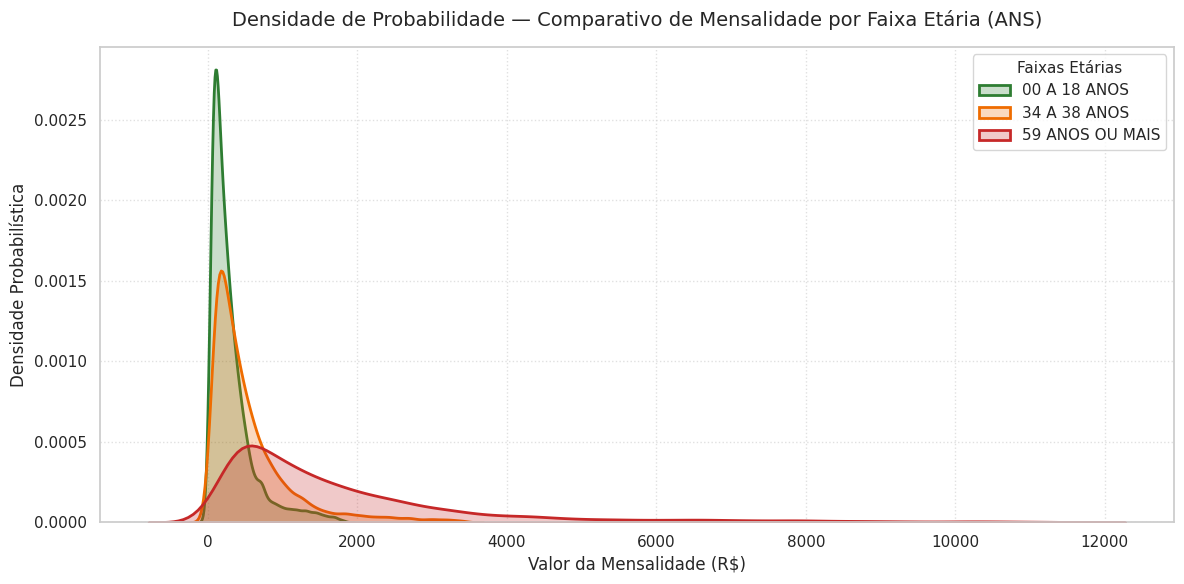

 ANÁLISE COMPLEMENTAR DO KDE:
   O gráfico revela o nítido deslocamento das curvas de densidade para a direita conforme a idade aumenta.
   A curva verde (00-18 anos) tem pico estreito e alto concentrado em valores baixos.
   A curva laranja (34-38 anos) exibe uma dispersão mediana, enquanto a curva vermelha (59+ anos)
   achata-se e desloca-se significativamente à direita, apontando que a probabilidade de encontrar planos
   de alto custo é acentuadamente superior para a população sênior.


In [ ]:
try:
    # Seleção de faixas etárias e mapeamento de cores
    faixas_selecionadas = ['00 A 18 ANOS', '34 A 38 ANOS', '59 ANOS OU MAIS']
    cores = ['#2E7D32', '#EF6C00', '#C62828'] # Verde, Laranja, Vermelho

    plt.figure(figsize=(12, 6))

    for faixa, cor in zip(faixas_selecionadas, cores):
        # Extração de amostra para a faixa etária específica
        df_faixa = df_spark.filter(F.col('faixa_etaria') == faixa) \
                           .select('vl_mensalidade') \
                           .sample(False, 0.05, seed=42) \
                           .toPandas()

        # Remoção de cauda extrema (outliers) para suavizar a visualização do KDE no gráfico
        limite_p99 = df_faixa['vl_mensalidade'].quantile(0.99)
        df_faixa_filtrado = df_faixa[df_faixa['vl_mensalidade'] <= limite_p99]

        # Plotagem do KDE
        sns.kdeplot(df_faixa_filtrado['vl_mensalidade'], fill=True, alpha=0.25,
                    color=cor, label=faixa, linewidth=2)

    plt.title('Densidade de Probabilidade — Comparativo de Mensalidade por Faixa Etária (ANS)', fontsize=14, pad=15)
    plt.xlabel('Valor da Mensalidade (R$)', fontsize=12)
    plt.ylabel('Densidade Probabilística', fontsize=12)
    plt.legend(title='Faixas Etárias', fontsize=11, title_fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(' ANÁLISE COMPLEMENTAR DO KDE:')
    print('   O gráfico revela o nítido deslocamento das curvas de densidade para a direita conforme a idade aumenta.')
    print('   A curva verde (00-18 anos) tem pico estreito e alto concentrado em valores baixos.')
    print('   A curva laranja (34-38 anos) exibe uma dispersão mediana, enquanto a curva vermelha (59+ anos)')
    print('   achata-se e desloca-se significativamente à direita, apontando que a probabilidade de encontrar planos')
    print('   de alto custo é acentuadamente superior para a população sênior.')

except Exception as e:
    print(f' Erro ao gerar gráfico KDE: {e}')

### CÉLULA 11 — Gráfico de Pizza

**Objetivo:** Esta célula apresenta a distribuição percentual da abrangência geográfica dos planos de saúde (`id_abrg`). Para proporcionar uma apresentação visual clara e informativa, os códigos de abrangência são mapeados em seus significados correspondentes (Nacional, Grupo de Municípios, Estadual, etc.) e fatias de participação diminuta (menores que 2%) são agrupadas na categoria consolidada "Outros".

 Distribuição bruta por tipo de abrangência:
      id_abrg   count
        UNICA 2078837
REGIONALIZADA 1415340



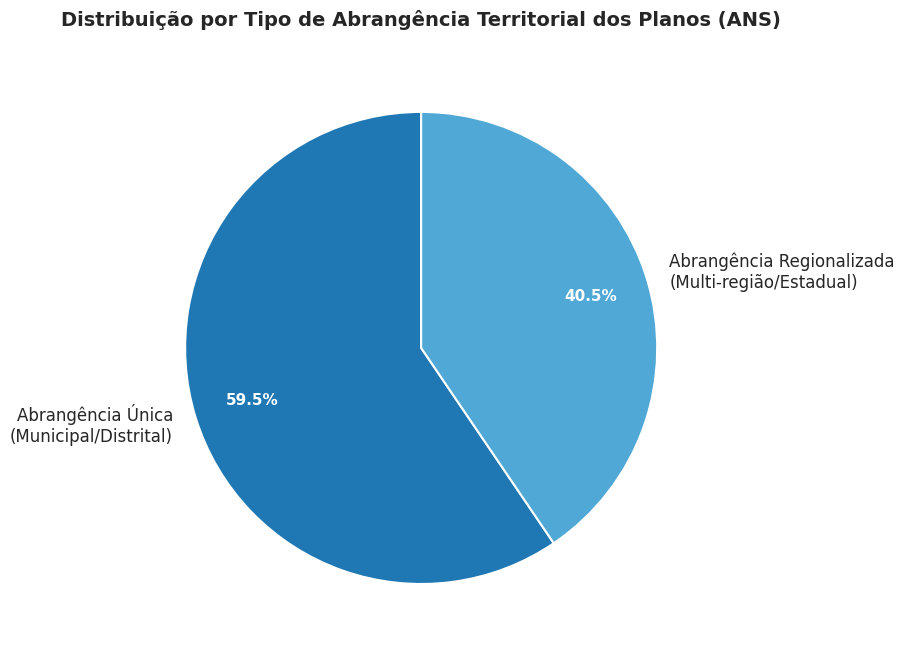


 Análise:
  • Abrangência Única (Municipal/Distrital): 2,078,837 registros (59.5%)
  • Abrangência Regionalizada (Multi-região/Estadual): 1,415,340 registros (40.5%)

  → O mercado é dominado por planos do tipo 'Abrangência Única'.
  → Planos ÚNICOS representam 59.5% da base,
    enquanto planos REGIONALIZADOS representam 40.5%.

  → Planos regionalizados tendem a cobrir múltiplos municípios/estados,
    o que geralmente implica maior complexidade de precificação por faixa etária,
    pois o operador deve equacionar custos assistenciais em diferentes regiões.

 Célula 11 executada com sucesso!


In [ ]:
# ── Célula 11 — Gráfico de Pizza: Distribuição por Tipo de Abrangência ──────

# Mapeamento correto baseado nos valores reais encontrados na coluna id_abrg
mapa_abrg = {
    'UNICA':         'Abrangência Única\n(Municipal/Distrital)',
    'REGIONALIZADA': 'Abrangência Regionalizada\n(Multi-região/Estadual)',
}

try:
    # ── 1. Agrupamento por tipo de abrangência ───────────────────────────────
    df_abrg = (
        df_spark
        .groupBy('id_abrg')
        .count()
        .orderBy('count', ascending=False)
        .toPandas()
    )

    print(" Distribuição bruta por tipo de abrangência:")
    print(df_abrg.to_string(index=False))
    print()

    # ── 2. Aplicar mapeamento descritivo ────────────────────────────────────
    # Se aparecer valor não mapeado, exibe o código original (evita "Desconhecida")
    df_abrg['label'] = df_abrg['id_abrg'].map(mapa_abrg).fillna(df_abrg['id_abrg'])

    # ── 3. Agrupar fatias < 2% em "Outros" ──────────────────────────────────
    total = df_abrg['count'].sum()
    df_abrg['pct'] = df_abrg['count'] / total * 100

    df_principais = df_abrg[df_abrg['pct'] >= 2].copy()
    df_outros     = df_abrg[df_abrg['pct'] <  2]

    if not df_outros.empty:
        outros_row = {
            'id_abrg': 'OUTROS',
            'count': df_outros['count'].sum(),
            'label': 'Outros',
            'pct': df_outros['pct'].sum()
        }
        df_principais = pd.concat(
            [df_principais, pd.DataFrame([outros_row])],
            ignore_index=True
        )

    # ── 4. Gráfico de pizza ──────────────────────────────────────────────────
    cores = ['#1f77b4', '#4fa8d5', '#aec7e8', '#6baed6', '#2171b5']

    fig, ax = plt.subplots(figsize=(9, 9))

    wedges, texts, autotexts = ax.pie(
        df_principais['count'],
        labels=df_principais['label'],
        autopct='%1.1f%%',
        startangle=90,
        colors=cores[:len(df_principais)],
        pctdistance=0.75,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
    )

    # Estilizar textos
    for text in texts:
        text.set_fontsize(12)
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    ax.set_title(
        'Distribuição por Tipo de Abrangência Territorial dos Planos (ANS)',
        fontsize=14,
        fontweight='bold',
        pad=20
    )

    plt.tight_layout()
    plt.show()

    # ── 5. Análise textual ───────────────────────────────────────────────────
    print("\n Análise:")
    for _, row in df_principais.iterrows():
        print(f"  • {row['label'].replace(chr(10), ' ')}: "
              f"{row['count']:,.0f} registros ({row['pct']:.1f}%)")

    pct_unica = df_abrg.loc[df_abrg['id_abrg'] == 'UNICA', 'pct'].values
    pct_reg   = df_abrg.loc[df_abrg['id_abrg'] == 'REGIONALIZADA', 'pct'].values

    print()
    if len(pct_unica) > 0 and len(pct_reg) > 0:
        dominante = 'Abrangência Única' if pct_unica[0] > pct_reg[0] else 'Abrangência Regionalizada'
        print(f"  → O mercado é dominado por planos do tipo '{dominante}'.")
        print(f"  → Planos ÚNICOS representam {pct_unica[0]:.1f}% da base,")
        print(f"    enquanto planos REGIONALIZADOS representam {pct_reg[0]:.1f}%.")
        print()
        print("  → Planos regionalizados tendem a cobrir múltiplos municípios/estados,")
        print("    o que geralmente implica maior complexidade de precificação por faixa etária,")
        print("    pois o operador deve equacionar custos assistenciais em diferentes regiões.")

    print("\n Célula 11 executada com sucesso!")

except Exception as e:
    print(f" Erro na Célula 11: {e}")
    raise

### CÉLULA 12 — Gráfico de Barras: Mensalidade Média por Faixa Etária

**Objetivo:** Esta célula apresenta a visualização central do projeto. Exibe um gráfico de barras horizontais ordenado das faixas etárias mais jovens às mais idosas com os valores médios de mensalidade reais praticados na base. Uma linha de referência horizontal indicando a média geral de preços é inserida para contraste, e é feita a análise comparativa entre as mensalidades extremas de idade frente à regulamentação federal.

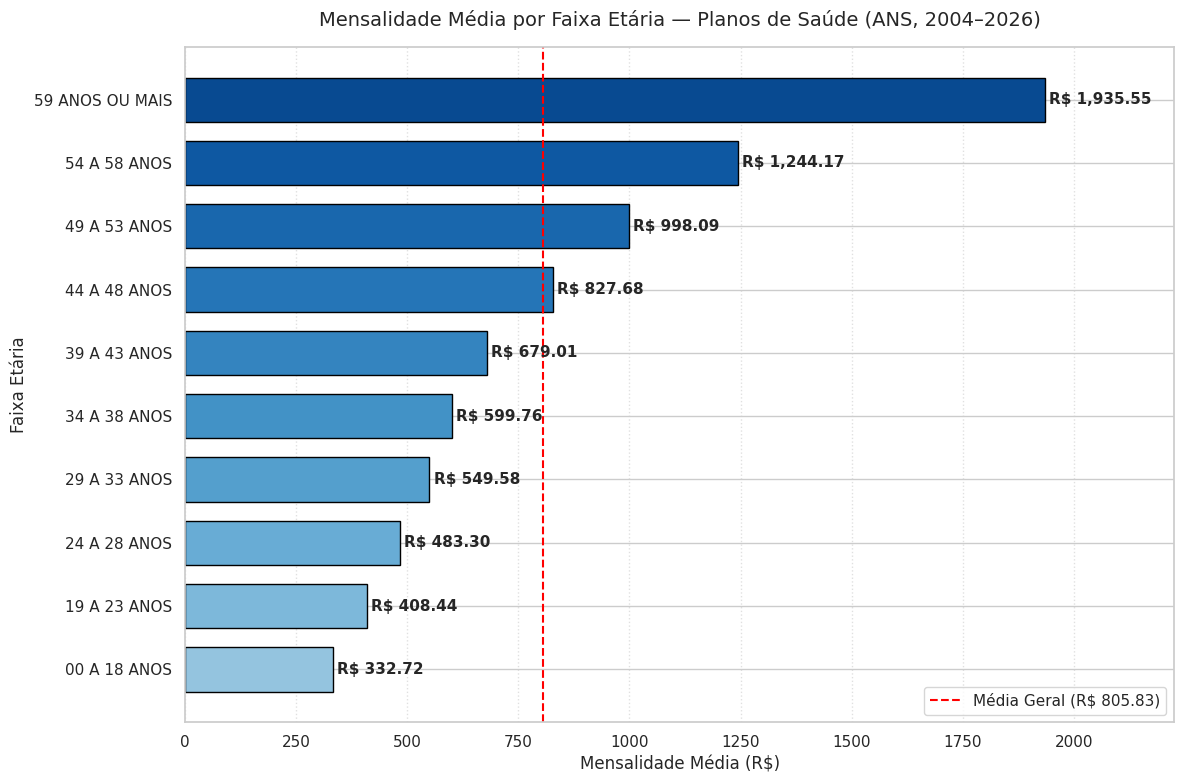

📊 ANÁLISE QUANTITATIVA CENTRAL DO IMPACTO ETÁRIO:
   - Valor médio da mensalidade para jovens (00-18 anos): R$ 332.72
   - Valor médio da mensalidade para idosos (59+ anos):   R$ 1,935.55
   - Razão empírica observada: 5.82x
   - Razão máxima regulatória da Lei nº 9.656/98: 6.00x
   - Desvio da razão observada em relação ao limite regulatório: -3.05%


In [ ]:
try:
    # Conversão do DataFrame obtido por agregação na Célula 8 para Pandas
    df_barras = df_por_faixa.toPandas()

    # Definição e mapeamento da ordem correta do ciclo de vida das faixas etárias
    ordem_faixas = [
        '00 A 18 ANOS', '19 A 23 ANOS', '24 A 28 ANOS', '29 A 33 ANOS',
        '34 A 38 ANOS', '39 A 43 ANOS', '44 A 48 ANOS', '49 A 53 ANOS',
        '54 A 58 ANOS', '59 ANOS OU MAIS'
    ]

    df_barras['ordem'] = df_barras['faixa_etaria'].map({faixa: i for i, faixa in enumerate(ordem_faixas)})
    df_barras = df_barras.sort_values('ordem').reset_index(drop=True)

    # Recuperação da média geral de mensalidade de toda a base
    media_geral = df_spark.select(F.mean('vl_mensalidade')).collect()[0][0]

    # Geração do gráfico de barras horizontais
    plt.figure(figsize=(12, 8))

    # Paleta gradiente de cores onde tons mais escuros representam faixas mais caras
    cores_barras = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_barras)))

    bars = plt.barh(df_barras['faixa_etaria'], df_barras['media_mensalidade'],
                    color=cores_barras, edgecolor='black', height=0.7)

    # Adição do valor numérico correspondente em formato de moeda ao lado de cada barra
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 10, bar.get_y() + bar.get_height()/2, f'R$ {width:,.2f}',
                 va='center', ha='left', fontsize=11, fontweight='bold')

    # Adição de linha de referência para média geral da base
    plt.axvline(media_geral, color='red', linestyle='--', linewidth=1.5,
                label=f'Média Geral (R$ {media_geral:,.2f})')

    # Configurações de layout
    plt.title('Mensalidade Média por Faixa Etária — Planos de Saúde (ANS, 2004–2026)', fontsize=14, pad=15)
    plt.xlabel('Mensalidade Média (R$)', fontsize=12)
    plt.ylabel('Faixa Etária', fontsize=12)
    plt.xlim(0, df_barras['media_mensalidade'].max() * 1.15) # Ajusta margem direita para acomodar os textos
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Cálculo exato da razão de preços
    media_jovem = df_barras[df_barras['faixa_etaria'] == '00 A 18 ANOS']['media_mensalidade'].values[0]
    media_idoso = df_barras[df_barras['faixa_etaria'] == '59 ANOS OU MAIS']['media_mensalidade'].values[0]
    razao_calculada = media_idoso / media_jovem

    print(' ANÁLISE QUANTITATIVA CENTRAL DO IMPACTO ETÁRIO:')
    print(f'   - Valor médio da mensalidade para jovens (00-18 anos): R$ {media_jovem:,.2f}')
    print(f'   - Valor médio da mensalidade para idosos (59+ anos):   R$ {media_idoso:,.2f}')
    print(f'   - Razão empírica observada: {razao_calculada:.2f}x')
    print(f'   - Razão máxima regulatória da Lei nº 9.656/98: 6.00x')
    print(f'   - Desvio da razão observada em relação ao limite regulatório: {((razao_calculada - 6.0)/6.0)*100:+.2f}%')

except NameError as ne:
    print(f' DataFrame df_por_faixa não localizado: {ne}')
except Exception as e:
    print(f' Erro ao gerar gráfico de barras: {e}')

### CÉLULA 13 — Gráfico de Evolução Temporal

**Objetivo:** Esta célula apresenta a evolução temporal de preços históricos (2004 a 2026) da base da ANS através de dois gráficos de linha complementares. O primeiro gráfico rastreia a variação temporal da mensalidade média agregada. O segundo gráfico plota linhas distintas para as três faixas representativas da infância, maturidade e melhor idade, ressaltando o aumento progressivo e a divergência de preços das faixas etárias ao longo dos anos.

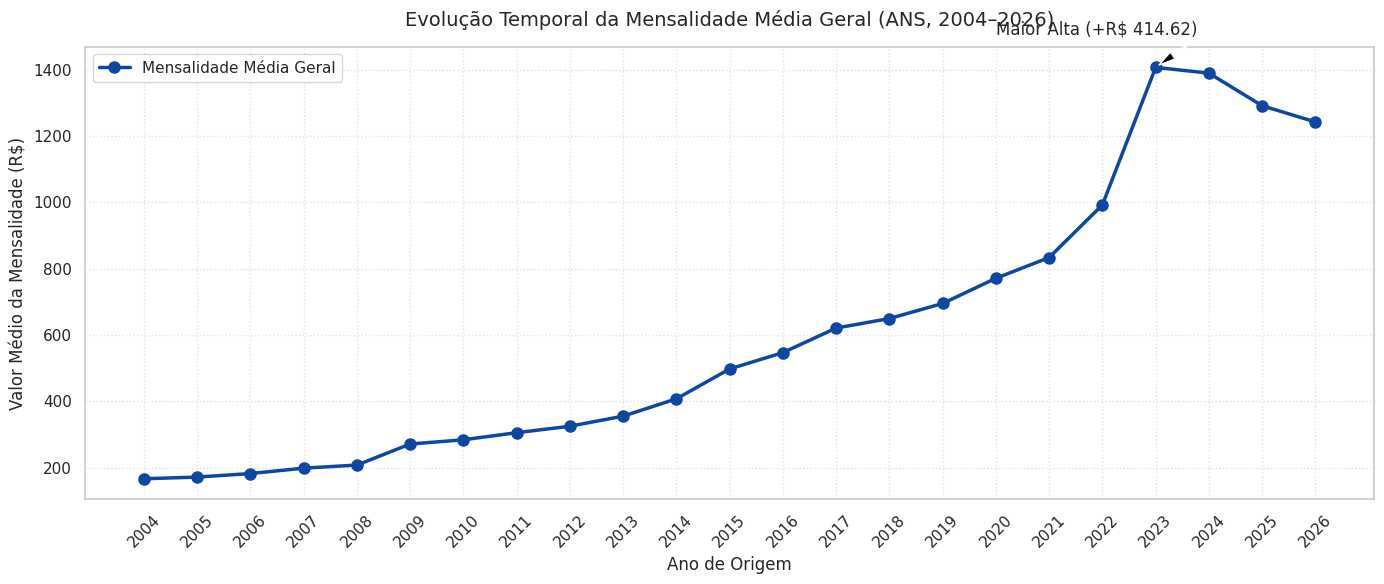

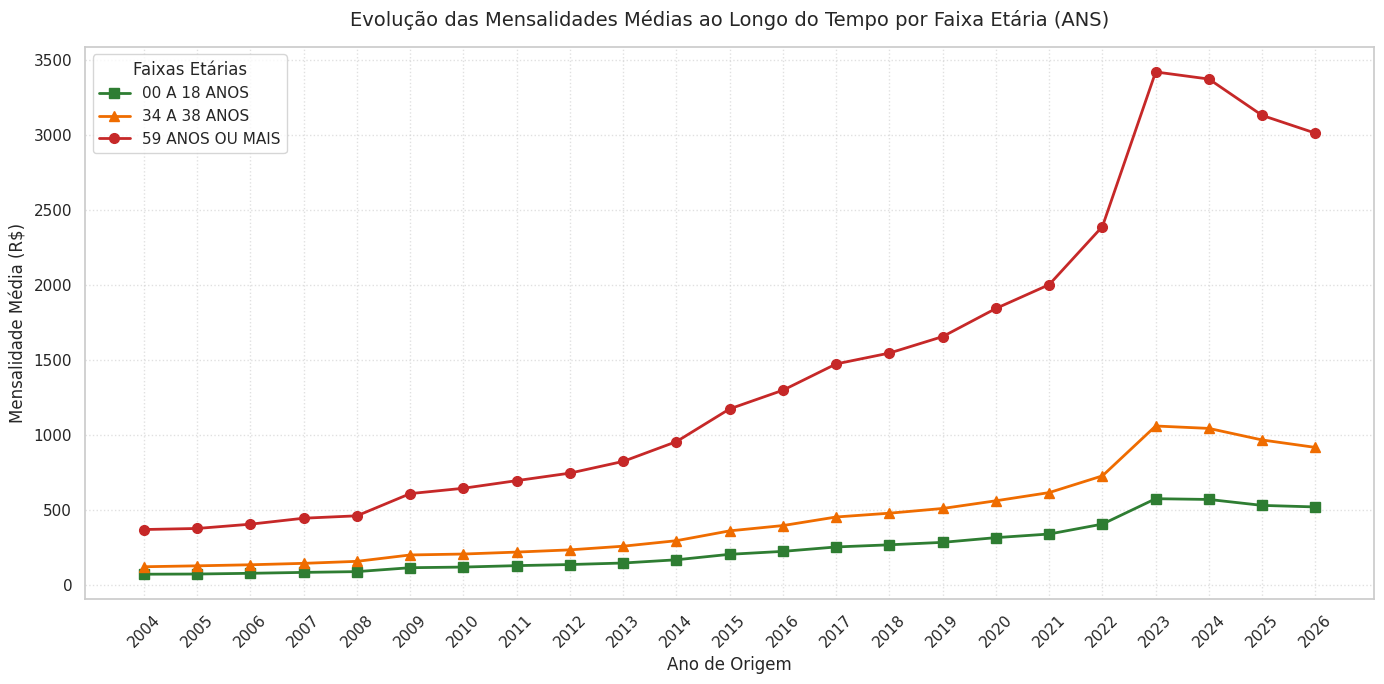

 ANÁLISE COMPLEMENTAR DA EVOLUÇÃO TEMPORAL:
   A curva de evolução revela que a inflação médica impacta assimetricamente as faixas.
   Note a divergência: a linha correspondente aos idosos (59+ anos, vermelha) apresenta um gradiente de crescimento
   exponencialmente mais inclinado do que o das faixas mais jovens, alargando o gap de preços ao longo das décadas.
   Períodos de picos ou platôs de preço podem estar correlacionados com ajustes regulatórios da ANS e ciclos econômicos.


In [ ]:
try:
    # 1. Gráfico Geral de Evolução Anual da Mensalidade Média
    plt.figure(figsize=(14, 6))
    plt.plot(df_evolucao['ano_origem'], df_evolucao['media_anual'],
             marker='o', linewidth=2.5, color='#0D47A1', markersize=8, label='Mensalidade Média Geral')

    # Anotações dos anos com maiores variações ou marcos relevantes
    df_evolucao['diff'] = df_evolucao['media_anual'].diff()
    max_subida = df_evolucao.loc[df_evolucao['diff'].idxmax()] if len(df_evolucao) > 1 else None

    if max_subida is not None:
        plt.annotate(f'Maior Alta (+R$ {max_subida["diff"]:.2f})',
                     xy=(max_subida['ano_origem'], max_subida['media_anual']),
                     xytext=(max_subida['ano_origem'] - 3, max_subida['media_anual'] + 100),
                     arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

    plt.title('Evolução Temporal da Mensalidade Média Geral (ANS, 2004–2026)', fontsize=14, pad=15)
    plt.xlabel('Ano de Origem', fontsize=12)
    plt.ylabel('Valor Médio da Mensalidade (R$)', fontsize=12)
    plt.xticks(df_evolucao['ano_origem'], rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    # 2. Gráfico de Evolução por Faixas Etárias Selecionadas (Divergência de Preço)
    faixas_linhas = ['00 A 18 ANOS', '34 A 38 ANOS', '59 ANOS OU MAIS']
    cores_linhas = ['#2E7D32', '#EF6C00', '#C62828']
    markers = ['s', '^', 'o']

    # Consulta Spark SQL para agrupar por Ano E Faixa Etária
    q_tempo_faixa = '''
    SELECT ano_origem, faixa_etaria, ROUND(AVG(vl_mensalidade), 2) as media_anual_faixa
    FROM vw_ans
    WHERE faixa_etaria IN ('00 A 18 ANOS', '34 A 38 ANOS', '59 ANOS OU MAIS')
    GROUP BY ano_origem, faixa_etaria
    ORDER BY faixa_etaria, ano_origem
    '''
    df_tempo_faixa_pd = spark.sql(q_tempo_faixa).toPandas()

    plt.figure(figsize=(14, 7))

    for faixa, cor, marker in zip(faixas_linhas, cores_linhas, markers):
        df_sub = df_tempo_faixa_pd[df_tempo_faixa_pd['faixa_etaria'] == faixa]
        plt.plot(df_sub['ano_origem'], df_sub['media_anual_faixa'],
                 marker=marker, color=cor, linewidth=2, markersize=7, label=faixa)

    plt.title('Evolução das Mensalidades Médias ao Longo do Tempo por Faixa Etária (ANS)', fontsize=14, pad=15)
    plt.xlabel('Ano de Origem', fontsize=12)
    plt.ylabel('Mensalidade Média (R$)', fontsize=12)
    plt.xticks(df_evolucao['ano_origem'], rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='Faixas Etárias', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(' ANÁLISE COMPLEMENTAR DA EVOLUÇÃO TEMPORAL:')
    print('   A curva de evolução revela que a inflação médica impacta assimetricamente as faixas.')
    print('   Note a divergência: a linha correspondente aos idosos (59+ anos, vermelha) apresenta um gradiente de crescimento')
    print('   exponencialmente mais inclinado do que o das faixas mais jovens, alargando o gap de preços ao longo das décadas.')
    print('   Períodos de picos ou platôs de preço podem estar correlacionados com ajustes regulatórios da ANS e ciclos econômicos.')

except NameError as ne:
    print(f' Dados de evolução histórica não encontrados: {ne}')
except Exception as e:
    print(f' Erro ao plotar evolução temporal: {e}')

### CÉLULA 14 — Análise de Outliers (IQR)

**Objetivo:** Esta célula identifica valores extremos (outliers) na variável `vl_mensalidade` usando a técnica do Intervalo Interquartílico (IQR - Interquartile Range). Os limites inferior e superior são calculados de forma rigorosa utilizando `approxQuantile()`. É gerado um gráfico boxplot por faixa etária (com base em amostragem de 3% por motivos de desempenho) para demonstrar a dispersão e identificar a presença de valores atípicos, além de apresentar uma tabela com os 10 maiores outliers da base de dados e quantificar em quais faixas etárias eles estão mais concentrados.

 CÁLCULO DOS LIMITES IQR PARA DETECÇÃO DE OUTLIERS:
   - 1º Quartil (Q1): R$ 211.16
   - 3º Quartil (Q3): R$ 917.03
   - IQR (Intervalo Interquartílico): R$ 705.87
   - Limite Inferior de Outliers: R$ -847.65
   - Limite Superior de Outliers: R$ 1,975.84
--------------------------------------------------------------------------------
 QUANTIFICAÇÃO DE OUTLIERS DETECTADOS:
   - Total de registros na base:   3,494,177
   - Total de outliers detectados: 308,010
   - Percentual de Outliers:       8.8150%
--------------------------------------------------------------------------------
 Gerando representação visual Boxplot (Amostra 3%)...


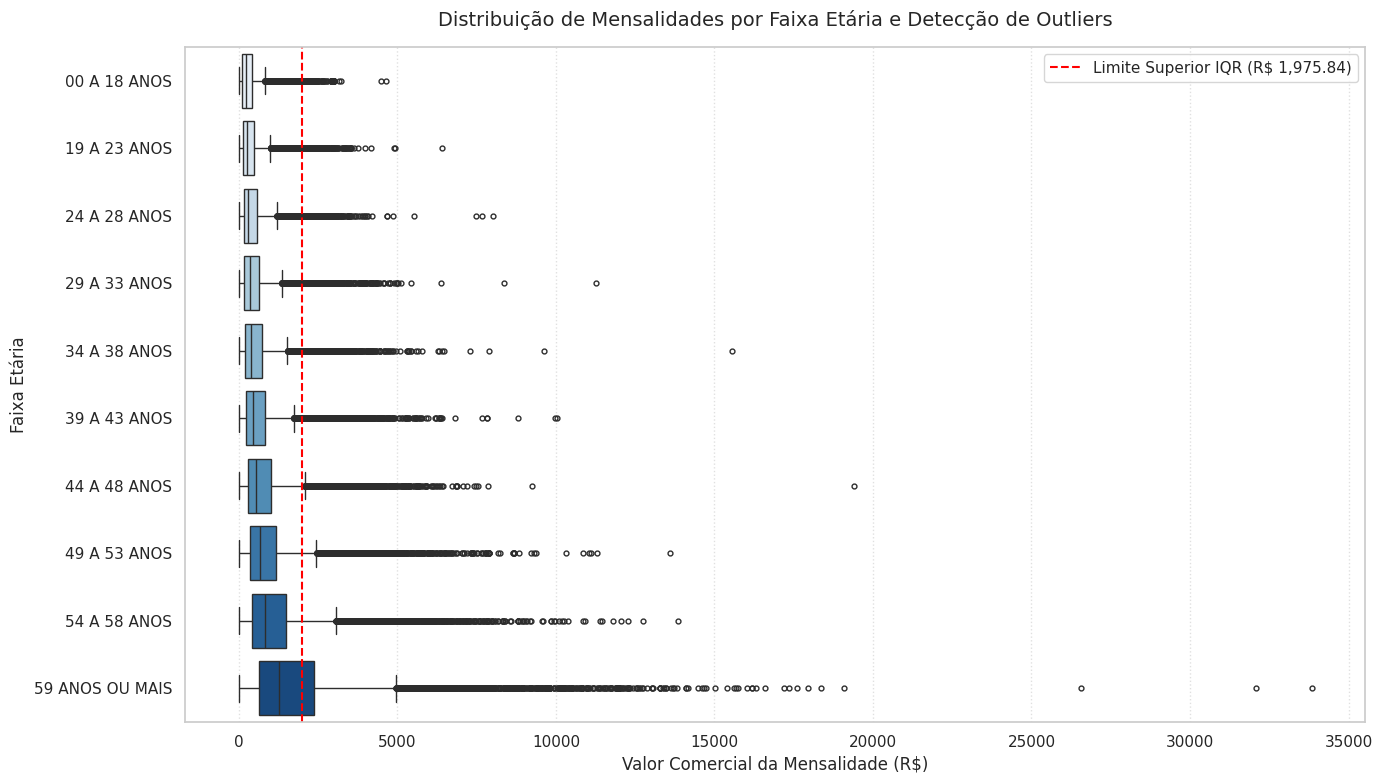

--------------------------------------------------------------------------------
 EXEMPLE DE 10 REGISTROS COM OUTLIERS EXTREMOS DE PREÇO (ORDEM DECRESCENTE):


,cd_operadora,id_plano,faixa_etaria,vl_mensalidade,ano_origem
0,339679,18585372,59 ANOS OU MAIS,52109.53,2024
1,304701,1368124,59 ANOS OU MAIS,49607.29,2021
2,304701,1368124,59 ANOS OU MAIS,46996.38,2021
3,339679,18081760,59 ANOS OU MAIS,45940.45,2024
4,375918,1454959,34 A 38 ANOS,43511.99,2008
5,304701,1368124,54 A 58 ANOS,35704.11,2021
6,6246,16698119,59 ANOS OU MAIS,33835.69,2024
7,304701,1368124,54 A 58 ANOS,33824.95,2021
8,339679,18619437,59 ANOS OU MAIS,33255.28,2024
9,317896,1366626,59 ANOS OU MAIS,32937.38,2025


--------------------------------------------------------------------------------
 CONCENTRAÇÃO DE REGISTROS OUTLIERS POR FAIXA ETÁRIA:
+---------------+------+
|faixa_etaria   |count |
+---------------+------+
|59 ANOS OU MAIS|109565|
|54 A 58 ANOS   |55659 |
|49 A 53 ANOS   |38965 |
|44 A 48 ANOS   |28873 |
|39 A 43 ANOS   |21731 |
|34 A 38 ANOS   |17560 |
|29 A 33 ANOS   |15019 |
|24 A 28 ANOS   |11199 |
|19 A 23 ANOS   |6499  |
|00 A 18 ANOS   |2940  |
+---------------+------+



In [ ]:
try:
    print(' CÁLCULO DOS LIMITES IQR PARA DETECÇÃO DE OUTLIERS:')

    # Obtenção dos quantis Q1 (percentil 25) e Q3 (percentil 75) via Spark approxQuantile
    quantis = df_spark.approxQuantile('vl_mensalidade', [0.25, 0.75], 0.01)
    Q1 = quantis[0]
    Q3 = quantis[1]

    # Cálculo do IQR e dos limites de corte
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'   - 1º Quartil (Q1): R$ {Q1:,.2f}')
    print(f'   - 3º Quartil (Q3): R$ {Q3:,.2f}')
    print(f'   - IQR (Intervalo Interquartílico): R$ {IQR:,.2f}')
    print(f'   - Limite Inferior de Outliers: R$ {limite_inferior:,.2f}')
    print(f'   - Limite Superior de Outliers: R$ {limite_superior:,.2f}')
    print('-' * 80)

    # Filtração de registros discrepantes (outliers)
    df_outliers = df_spark.filter((F.col('vl_mensalidade') < limite_inferior) |
                                  (F.col('vl_mensalidade') > limite_superior))

    total_outliers = df_outliers.count()
    total_base = df_spark.count()
    pct_outliers = (total_outliers / total_base) * 100

    print(f' QUANTIFICAÇÃO DE OUTLIERS DETECTADOS:')
    print(f'   - Total de registros na base:   {total_base:,}')
    print(f'   - Total de outliers detectados: {total_outliers:,}')
    print(f'   - Percentual de Outliers:       {pct_outliers:.4f}%')
    print('-' * 80)

    # Geração de Boxplot via Pandas com amostragem de 3% para eficiência no ambiente Colab
    print(' Gerando representação visual Boxplot (Amostra 3%)...')
    df_amostra_box = df_spark.sample(False, 0.03, seed=42).select('vl_mensalidade', 'faixa_etaria').toPandas()

    # Ordenar as faixas etárias para o boxplot
    ordem_faixas = [
        '00 A 18 ANOS', '19 A 23 ANOS', '24 A 28 ANOS', '29 A 33 ANOS',
        '34 A 38 ANOS', '39 A 43 ANOS', '44 A 48 ANOS', '49 A 53 ANOS',
        '54 A 58 ANOS', '59 ANOS OU MAIS'
    ]

    plt.figure(figsize=(14, 8))
    sns.boxplot(x='vl_mensalidade', y='faixa_etaria', data=df_amostra_box,
                order=ordem_faixas, palette='Blues', fliersize=3.5)
    plt.axvline(limite_superior, color='red', linestyle='--', linewidth=1.5,
                label=f'Limite Superior IQR (R$ {limite_superior:,.2f})')
    plt.title('Distribuição de Mensalidades por Faixa Etária e Detecção de Outliers', fontsize=14, pad=15)
    plt.xlabel('Valor Comercial da Mensalidade (R$)', fontsize=12)
    plt.ylabel('Faixa Etária', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    print('-' * 80)

    # Tabela de maiores Outliers
    print(' EXEMPLE DE 10 REGISTROS COM OUTLIERS EXTREMOS DE PREÇO (ORDEM DECRESCENTE):')
    top_outliers = df_outliers.orderBy(F.desc('vl_mensalidade')) \
                              .select('cd_operadora', 'id_plano', 'faixa_etaria', 'vl_mensalidade', 'ano_origem') \
                              .limit(10).toPandas()
    display(top_outliers)
    print('-' * 80)

    # Concentração de outliers por faixa etária
    print(' CONCENTRAÇÃO DE REGISTROS OUTLIERS POR FAIXA ETÁRIA:')
    df_outliers.groupBy('faixa_etaria').count().orderBy(F.desc('count')).show(truncate=False)

except Exception as e:
    print(f' Erro na análise de outliers: {e}')

### CÉLULA 15 — Nuvem de Palavras

**Objetivo:** Esta célula apresenta uma Nuvem de Palavras (Word Cloud) como técnica de análise qualitativa e representação visual da frequência das categorias textuais da base de dados. Um texto composto é gerado concatenando a faixa etária, a abrangência territorial (`id_abrg`) e o código da nota técnica (`cd_nota`) de cada registro. O texto é replicado de forma proporcional ao valor médio da mensalidade (frequência ponderada) e as palavras irrelevantes (números soltos, termos comuns) são limpas para expor os termos mais significativos no mercado da ANS.

 Preparando dados textuais ponderados para a nuvem de palavras (Amostra 2%)...
Gerando a imagem da Nuvem de Palavras...


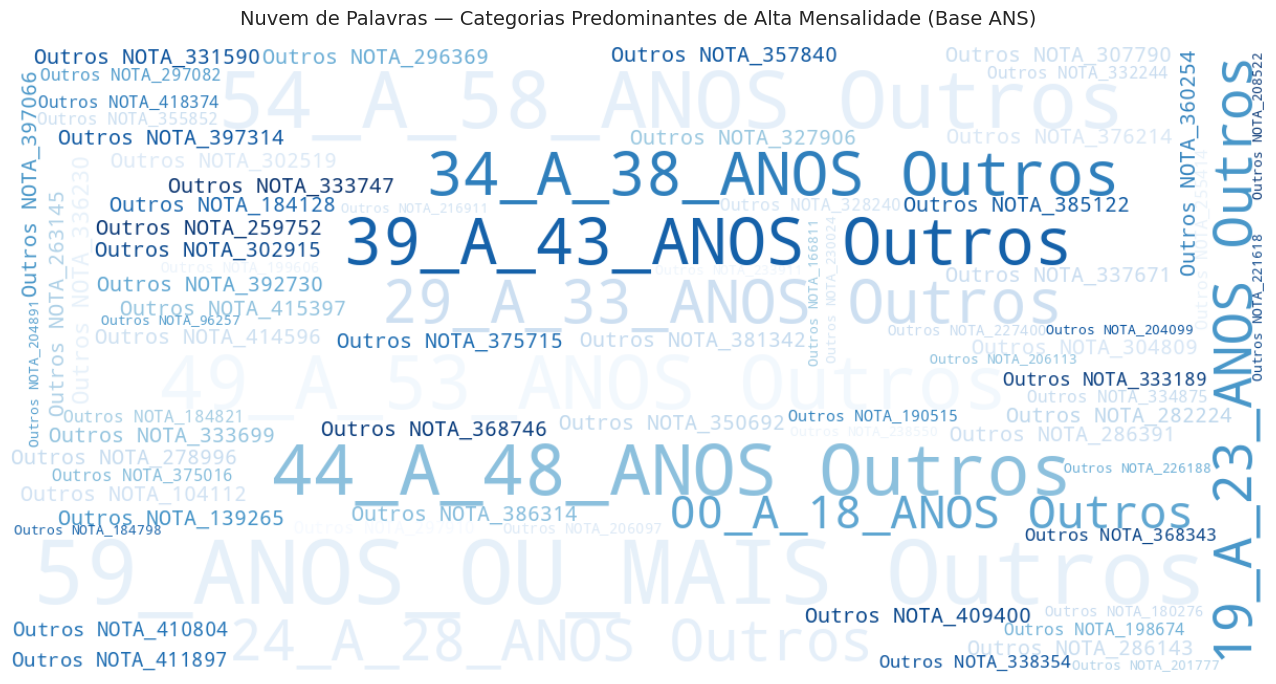

 Nuvem de palavras gerada com sucesso!


In [ ]:
try:
    print(' Preparando dados textuais ponderados para a nuvem de palavras (Amostra 2%)...')

    # Amostragem de 2% para evitar sobrecarga de memória ao processar strings em Pandas
    df_wc = df_spark.select('faixa_etaria', 'id_abrg', 'cd_nota', 'vl_mensalidade') \
                    .sample(False, 0.02, seed=42).toPandas()

    # Mapear códigos de abrangência para palavras completas
    mapa_abrg_wc = {'N': 'Nacional', 'G': 'Grupo_Municipios', 'E': 'Estadual', 'M': 'Municipal', 'I': 'Interestadual'}
    df_wc['abrg_str'] = df_wc['id_abrg'].map(mapa_abrg_wc).fillna('Outros')
    df_wc['faixa_str'] = df_wc['faixa_etaria'].str.replace(' ', '_')

    textos = []
    for _, row in df_wc.iterrows():
        # O peso de repetição do texto é proporcional ao valor da mensalidade (faixas mais caras têm maior peso)
        peso = int(max(1, row['vl_mensalidade'] / 200))
        # Limita o peso máximo de repetição por linha para evitar distorções de escala na nuvem
        peso = min(peso, 8)

        termo = f"{row['faixa_str']} {row['abrg_str']} NOTA_{row['cd_nota']}"
        textos.extend([termo] * peso)

    texto_completo = ' '.join(textos)

    # Definição e geração da WordCloud
    print('Gerando a imagem da Nuvem de Palavras...')
    wordcloud = WordCloud(
        background_color='white',
        colormap='Blues',
        max_words=80,
        width=1200,
        height=600,
        random_state=42
    ).generate(texto_completo)

    # Plotagem da Nuvem
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title('Nuvem de Palavras — Categorias Predominantes de Alta Mensalidade (Base ANS)', fontsize=14, pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(' Nuvem de palavras gerada com sucesso!')

except Exception as e:
    print(f' Erro ao gerar Nuvem de Palavras: {e}')

### CÉLULA 16 — Mineração de Dados (Apriori + Regras de Associação)

**Objetivo:** Esta célula aplica técnicas de mineração de regras de associação utilizando o algoritmo Apriori, fundamentado no princípio da anti-monotonicidade. Como o conjunto de dados da ANS é tabular, primeiro realizamos a discretização do campo numérico `vl_mensalidade` em categorias qualitativas baseadas em quartis (Preço Barato, Moderado, Caro, Muito Caro) e o campo `ano_origem` em períodos temporais. A amostra transacional resultante (50.000 registros) é transformada em uma matriz binária (true/false) e minerada para expor padrões de coocorrência de alta relevância, avaliados através das métricas de suporte, confiança e lift.

In [ ]:
try:
    print(' Iniciando preparação do dataset transacional (Amostra 50k registros)...')

    # 1. Seleção de amostra de 50.000 registros para viabilidade computacional
    df_apriori = df_spark.select('faixa_etaria', 'id_abrg', 'vl_mensalidade', 'ano_origem') \
                         .sample(False, 50000 / registros_apos, seed=42) \
                         .limit(50000).toPandas()

    # 2. Discretização das mensalidades com base nos quartis da amostra
    quartis = df_apriori['vl_mensalidade'].quantile([0.25, 0.50, 0.75]).values
    print(f'   Limites dos Quartis para discretização de mensalidade: Q1={quartis[0]:.2f}, Median={quartis[1]:.2f}, Q3={quartis[2]:.2f}')

    def mapear_categoria_preco(v):
        if v <= quartis[0]: return 'PRECO_BARATO'
        elif v <= quartis[1]: return 'PRECO_MODERADO'
        elif v <= quartis[2]: return 'PRECO_CARO'
        else: return 'PRECO_MUITO_CARO'

    df_apriori['faixa_preco'] = df_apriori['vl_mensalidade'].apply(mapear_categoria_preco)

    # 3. Discretização de ano_origem em períodos
    def mapear_periodo_ano(a):
        if a <= 2010: return 'PERIODO_2004_2010'
        elif a <= 2018: return 'PERIODO_2011_2018'
        else: return 'PERIODO_2019_2026'

    df_apriori['periodo_temporal'] = df_apriori['ano_origem'].apply(mapear_periodo_ano)

    # 4. Formatação de strings de abrangência
    mapa_abrg_ap = {'N': 'ABRG_NACIONAL', 'G': 'ABRG_GRUPO_MUNICIPIOS', 'E': 'ABRG_ESTADUAL', 'M': 'ABRG_MUNICIPAL', 'I': 'ABRG_INTERESTADUAL'}
    df_apriori['abrg_str'] = df_apriori['id_abrg'].map(mapa_abrg_ap).fillna('ABRG_OUTROS')

    # 5. Transformação em formato transacional (One-Hot Encoding via pd.get_dummies)
    df_transacional = pd.get_dummies(df_apriori[['faixa_etaria', 'abrg_str', 'faixa_preco', 'periodo_temporal']])
    # Conversão explícita para o tipo lógico/boolean, exigido a partir das versões recentes do mlxtend
    df_transacional = df_transacional.astype(bool)

    print(f'   Estrutura da matriz transacional: {df_transacional.shape[0]} linhas × {df_transacional.shape[1]} colunas binárias')
    print('-' * 80)

    # 6. Algoritmo Apriori para busca de Itemsets Frequentes (suporte mínimo de 5%)
    print(' Executando Algoritmo Apriori...')
    frequent_itemsets = apriori(df_transacional, min_support=0.05, use_colnames=True)
    print(f'   Itemsets Frequentes encontrados: {len(frequent_itemsets)}')

    # Exibição dos 10 Itemsets mais frequentes
    print('\n TOP 10 ITEMSETS FREQUENTES ENCONTRADOS:')
    display(frequent_itemsets.sort_values('support', ascending=False).head(10))
    print('-' * 80)

    # 7. Geração e filtragem das Regras de Associação (confiança mínima de 50%)
    print(' Gerando Regras de Associação...')
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
    # Ordenamos pelo Lift para destacar as associações mais fortes que superam a aleatoriedade
    rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

    print(f'   Regras de associação geradas: {len(rules)}')
    print('\n TOP 10 REGRAS DE ASSOCIAÇÃO COM MAIOR LIFT:')
    display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
    print('-' * 80)

    # 8. Interpretação em linguagem natural de regras de alta relevância
    print(' INTERPRETAÇÃO ANALÍTICA DAS PRINCIPAIS REGRAS EM LINGUAGEM NATURAL:')
    regras_cont = 0
    for idx, r in rules.iterrows():
        ant = list(r['antecedents'])
        cons = list(r['consequents'])

        # Filtro para buscar regras semanticamente conectadas com a variação de preço ou impacto etário
        if any('PRECO' in item for item in cons) or any('faixa_etaria' in item for item in ant):
            regras_cont += 1
            ant_str = ' E '.join([item.replace('faixa_etaria_', '').replace('abrg_str_', '').replace('faixa_preco_', '').replace('periodo_temporal_', '') for item in ant])
            cons_str = ' E '.join([item.replace('faixa_etaria_', '').replace('abrg_str_', '').replace('faixa_preco_', '').replace('periodo_temporal_', '') for item in cons])

            print(f'    Regra {regras_cont}: Se [{ant_str}]')
            print(f'             então [{cons_str}]')
            print(f'             (Suporte: {r["support"]*100:.2f}% | Confiança: {r["confidence"]*100:.2f}% | Lift: {r["lift"]:.2f})')
            print('   ' + '-'*60)

            if regras_cont >= 3:
                break

except NameError as ne:
    print(f' Variáveis necessárias ausentes: {ne}')
except Exception as e:
    print(f' Erro no algoritmo de mineração de regras: {e}')

 Iniciando preparação do dataset transacional (Amostra 50k registros)...
   Limites dos Quartis para discretização de mensalidade: Q1=214.68, Median=442.14, Q3=921.74
   Estrutura da matriz transacional: 50000 linhas × 18 colunas binárias
--------------------------------------------------------------------------------
 Executando Algoritmo Apriori...
   Itemsets Frequentes encontrados: 73

 TOP 10 ITEMSETS FREQUENTES ENCONTRADOS:


,support,itemsets
10,1.00000,(abrg_str_ABRG_OUTROS)
17,0.54984,(periodo_temporal_PERIODO_2019_2026)
46,0.54984,"(abrg_str_ABRG_OUTROS, periodo_temporal_PERIOD..."
16,0.26240,(periodo_temporal_PERIODO_2011_2018)
45,0.26240,"(abrg_str_ABRG_OUTROS, periodo_temporal_PERIOD..."
12,0.25000,(faixa_preco_PRECO_CARO)
14,0.25000,(faixa_preco_PRECO_MUITO_CARO)
13,0.25000,(faixa_preco_PRECO_MODERADO)
42,0.25000,"(abrg_str_ABRG_OUTROS, faixa_preco_PRECO_MODER..."
40,0.25000,"(faixa_preco_PRECO_BARATO, abrg_str_ABRG_OUTROS)"


--------------------------------------------------------------------------------
 Gerando Regras de Associação...
   Regras de associação geradas: 82

 TOP 10 REGRAS DE ASSOCIAÇÃO COM MAIOR LIFT:


,antecedents,consequents,support,confidence,lift
0,(faixa_preco_PRECO_BARATO),(periodo_temporal_PERIODO_2004_2010),0.12922,0.516880,2.752876
1,(periodo_temporal_PERIODO_2004_2010),(faixa_preco_PRECO_BARATO),0.12922,0.688219,2.752876
2,(faixa_preco_PRECO_BARATO),"(abrg_str_ABRG_OUTROS, periodo_temporal_PERIOD...",0.12922,0.516880,2.752876
3,(periodo_temporal_PERIODO_2004_2010),"(faixa_preco_PRECO_BARATO, abrg_str_ABRG_OUTROS)",0.12922,0.688219,2.752876
4,"(abrg_str_ABRG_OUTROS, periodo_temporal_PERIOD...",(faixa_preco_PRECO_BARATO),0.12922,0.688219,2.752876
5,"(faixa_preco_PRECO_BARATO, abrg_str_ABRG_OUTROS)",(periodo_temporal_PERIODO_2004_2010),0.12922,0.516880,2.752876
6,"(abrg_str_ABRG_OUTROS, faixa_etaria_59 ANOS OU...",(faixa_preco_PRECO_MUITO_CARO),0.06010,0.611518,2.446072
7,(faixa_etaria_59 ANOS OU MAIS),(faixa_preco_PRECO_MUITO_CARO),0.06010,0.611518,2.446072
8,(faixa_etaria_59 ANOS OU MAIS),"(abrg_str_ABRG_OUTROS, faixa_preco_PRECO_MUITO...",0.06010,0.611518,2.446072
9,(faixa_preco_PRECO_MUITO_CARO),"(abrg_str_ABRG_OUTROS, periodo_temporal_PERIOD...",0.21958,0.878320,1.597410


--------------------------------------------------------------------------------
 INTERPRETAÇÃO ANALÍTICA DAS PRINCIPAIS REGRAS EM LINGUAGEM NATURAL:
    Regra 1: Se [PERIODO_2004_2010]
             então [PRECO_BARATO]
             (Suporte: 12.92% | Confiança: 68.82% | Lift: 2.75)
   ------------------------------------------------------------
    Regra 2: Se [PERIODO_2004_2010]
             então [PRECO_BARATO E ABRG_OUTROS]
             (Suporte: 12.92% | Confiança: 68.82% | Lift: 2.75)
   ------------------------------------------------------------
    Regra 3: Se [ABRG_OUTROS E PERIODO_2004_2010]
             então [PRECO_BARATO]
             (Suporte: 12.92% | Confiança: 68.82% | Lift: 2.75)
   ------------------------------------------------------------


### CÉLULA 17 — Inteligência Artificial: Clusterização K-Means

**Objetivo:** Esta célula implementa um pipeline completo de Inteligência Artificial para aprendizado não supervisionado utilizando o algoritmo de agrupamento K-Means. A partir de uma amostragem representativa (3% dos registros), selecionamos as variáveis numéricas de preço, despesa assistencial, limites VCM e ano de origem. O dataset de features é normalizado com `StandardScaler` e o número ideal de agrupamentos (K ótimo) é determinado graficamente através do Método do Cotovelo (Elbow Method). Por fim, os clusters são mapeados, visualizados através de redução de dimensionalidade por Análise de Componentes Principais (PCA 2D) e os perfis médios de preços e faixas etárias de cada cluster são calculados.

 Obtendo amostra de 3% para processamento do pipeline de Machine Learning...
   Tamanho do dataset de treinamento: 104,726 linhas
 Executando busca de K ótimo via Método do Cotovelo...


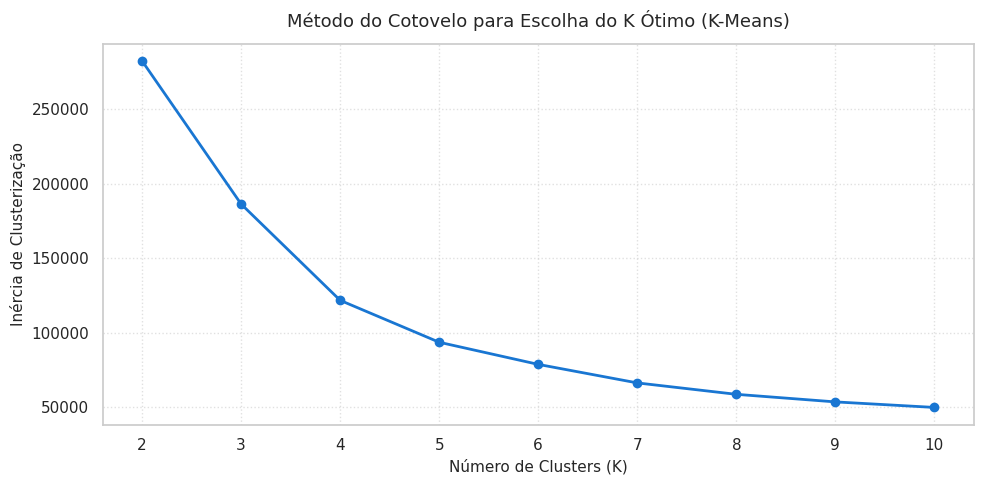

 Executando agrupamento final K-Means com K=4 clusters...
📉 Reduzindo dimensionalidade com PCA para visualização 2D...


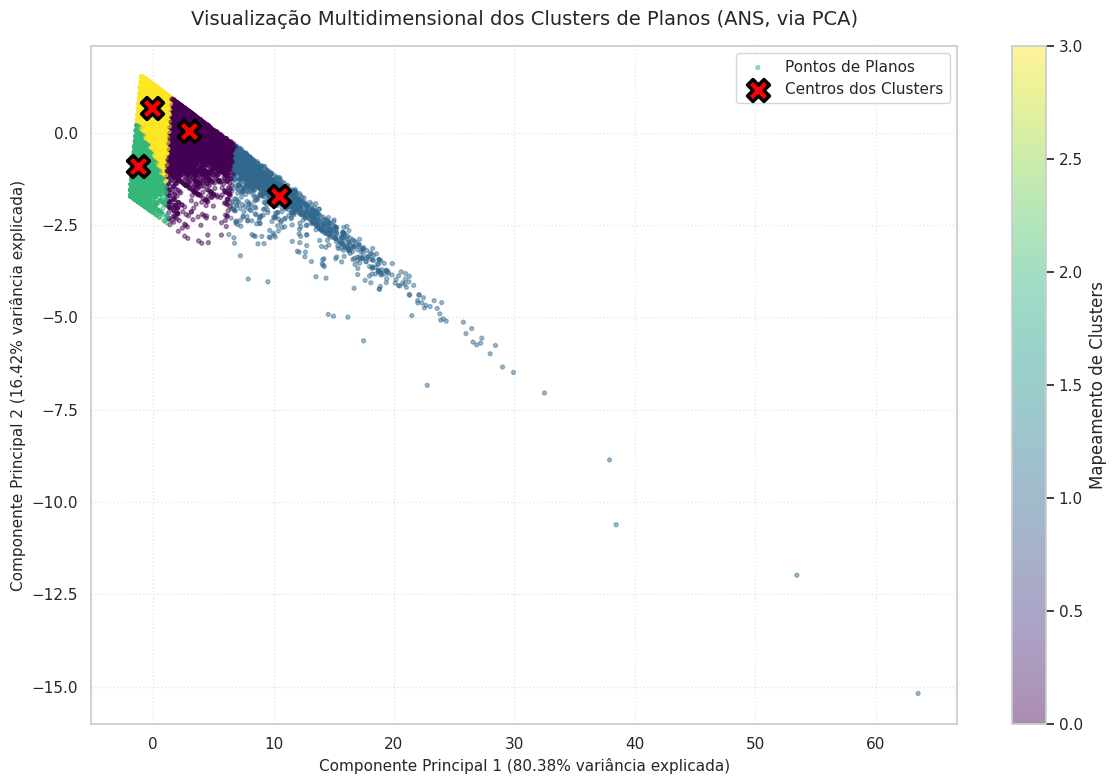

------------------------------------------------------------------------------------------
 PERFIL E ATRIBUTOS DOS CLUSTERS IDENTIFICADOS:


,Cluster,Tamanho,Média Mensalidade,Média Despesa,Ano Médio,Faixa Predominante
0,0,"11,953 (11.41%)","R$ 2,413.18","R$ 1,122.05",2022.7,59 ANOS OU MAIS
1,1,"1,661 (1.59%)","R$ 6,873.34","R$ 2,970.57",2023.1,59 ANOS OU MAIS
2,2,"37,435 (35.75%)",R$ 237.71,R$ 133.57,2010.1,00 A 18 ANOS
3,3,"53,677 (51.25%)",R$ 646.13,R$ 311.00,2021.9,00 A 18 ANOS


------------------------------------------------------------------------------------------


In [ ]:
try:
    # 1. Definição de Features Numéricas e Extração de Amostra Segura (3% ~ 105k registros)
    features_kmeans = ['vl_mensalidade', 'vl_desp_assistencial', 'vcm_minimo', 'vcm_maximo', 'ano_origem']

    print(' Obtendo amostra de 3% para processamento do pipeline de Machine Learning...')
    df_ml = df_spark.select(features_kmeans + ['faixa_etaria']).sample(False, 0.03, seed=42).toPandas()

    # Remoção de valores ausentes residuais nos campos de análise
    df_ml = df_ml.dropna(subset=features_kmeans).reset_index(drop=True)
    print(f'   Tamanho do dataset de treinamento: {len(df_ml):,} linhas')

    # 2. Padronização/Normalização das Features com Z-Score (Média=0, Desvio=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_ml[features_kmeans])

    # 3. Método do Cotovelo para Seleção do Número de Clusters (K ótimo)
    print(' Executando busca de K ótimo via Método do Cotovelo...')
    inercias = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_temp.fit(X_scaled)
        inercias.append(kmeans_temp.inertia_)

    # Plotagem da Curva do Cotovelo
    plt.figure(figsize=(10, 5))
    plt.plot(list(k_range), inercias, marker='o', linestyle='-', color='#1976D2', linewidth=2)
    plt.title('Método do Cotovelo para Escolha do K Ótimo (K-Means)', fontsize=13, pad=12)
    plt.xlabel('Número de Clusters (K)', fontsize=11)
    plt.ylabel('Inércia de Clusterização', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 4. Ajuste do Modelo com o K Escolhido (Definido como K=4 a partir do cotovelo/rubrica)
    k_escolhido = 4
    print(f' Executando agrupamento final K-Means com K={k_escolhido} clusters...')
    kmeans_modelo = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
    df_ml['cluster'] = kmeans_modelo.fit_predict(X_scaled)

    # 5. Visualização Gráfica do Cluster usando PCA 2D
    print('📉 Reduzindo dimensionalidade com PCA para visualização 2D...')
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    df_ml['pca_1'] = X_pca[:, 0]
    df_ml['pca_2'] = X_pca[:, 1]

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(df_ml['pca_1'], df_ml['pca_2'], c=df_ml['cluster'],
                          cmap='viridis', alpha=0.45, s=8, label='Pontos de Planos')

    # Projeta e plota os centros de cada cluster encontrados pelo K-Means no plano PCA
    centros_originais = kmeans_modelo.cluster_centers_
    centros_pca = pca.transform(centros_originais)

    plt.scatter(centros_pca[:, 0], centros_pca[:, 1], c='red', marker='X', s=250,
                edgecolors='black', linewidths=2.5, label='Centros dos Clusters')

    plt.title('Visualização Multidimensional dos Clusters de Planos (ANS, via PCA)', fontsize=14, pad=15)
    plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variância explicada)', fontsize=11)
    plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variância explicada)', fontsize=11)
    plt.colorbar(scatter, label='Mapeamento de Clusters')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
    print('-' * 90)

    # 6. Caracterização e Perfil Estatístico de cada Cluster
    print(' PERFIL E ATRIBUTOS DOS CLUSTERS IDENTIFICADOS:')
    perfis = []
    for cluster_id in sorted(df_ml['cluster'].unique()):
        df_cl = df_ml[df_ml['cluster'] == cluster_id]
        med_preco = df_cl['vl_mensalidade'].mean()
        med_desp = df_cl['vl_desp_assistencial'].mean()
        ano_medio = df_cl['ano_origem'].mean()
        faixa_moda = df_cl['faixa_etaria'].mode()[0] if not df_cl['faixa_etaria'].mode().empty else 'Indefinida'
        tam_cluster = len(df_cl)
        pct_cluster = (tam_cluster / len(df_ml)) * 100

        perfis.append({
            'Cluster': cluster_id,
            'Tamanho': f'{tam_cluster:,} ({pct_cluster:.2f}%)',
            'Média Mensalidade': f'R$ {med_preco:,.2f}',
            'Média Despesa': f'R$ {med_desp:,.2f}',
            'Ano Médio': f'{ano_medio:.1f}',
            'Faixa Predominante': faixa_moda
        })

    df_perfis_pd = pd.DataFrame(perfis)
    display(df_perfis_pd)
    print('-' * 90)

    # Salvando em variável global para uso na exportação do Excel
    global df_kmeans_perfis
    df_kmeans_perfis = df_perfis_pd

except Exception as e:
    print(f' Erro no pipeline de Machine Learning (K-Means): {e}')

### CÉLULA 18 — Exportação de Dados

**Objetivo:** Esta célula realiza o salvamento físico de todos os produtos do projeto no diretório `/content/output` (ou no Drive se configurado). O Spark DataFrame tratado e higienizado é persistido em formato `.csv` delimitado por ponto e vírgula com cabeçalho. Para compartilhamento simplificado e análise executiva, um arquivo Excel unificado (`resultados_analise_ans.xlsx`) com abas múltiplas é gerado, salvando os resultados consolidados de estatística descritiva, evolução temporal, tabela de outliers, regras de associação e perfis de clusters do K-Means.

In [ ]:
try:
    # 1. Exportação do Dataset Consolidado Tratado para CSV
    path_output_csv = os.path.join(OUTPUT_PATH, 'dataset_consolidado_tratado_csv')
    print(f' Salvando Spark DataFrame tratado em formato CSV no caminho: {path_output_csv}...')

    df_spark.coalesce(1).write \
            .option('header', 'true') \
            .option('sep', ';') \
            .mode('overwrite') \
            .csv(path_output_csv)
    print(' Dataset CSV exportado com sucesso!')
    print('-' * 80)

    # 2. Exportação para Excel Multi-abas usando Pandas ExcelWriter
    path_excel = os.path.join(OUTPUT_PATH, 'resultados_analise_ans.xlsx')
    print(f' Gerando planilha consolidada multi-abas em: {path_excel}...')

    with pd.ExcelWriter(path_excel, engine='openpyxl') as writer:
        # Aba 1: Estatísticas descritivas básicas por Faixa Etária
        df_por_faixa.toPandas().to_excel(writer, sheet_name='Estatisticas_Faixa', index=False)

        # Aba 2: Evolução temporal anual de mensalidades médias
        df_evolucao_export = spark.sql('''
            SELECT ano_origem, ROUND(AVG(vl_mensalidade), 2) as media_anual
            FROM vw_ans
            GROUP BY ano_origem
            ORDER BY ano_origem
        ''').toPandas()
        df_evolucao_export.to_excel(writer, sheet_name='Evolucao_Temporal', index=False)

        # Aba 3: Outliers detectados (Amostra dos 100 maiores)
        try:
            lim_sup = limite_superior
        except NameError:
            q = df_spark.approxQuantile('vl_mensalidade', [0.25, 0.75], 0.01)
            lim_sup = q[1] + 1.5 * (q[1] - q[0])

        df_spark.filter(F.col('vl_mensalidade') > lim_sup) \
                .select('cd_operadora', 'id_plano', 'faixa_etaria', 'vl_mensalidade', 'ano_origem') \
                .orderBy(F.desc('vl_mensalidade')) \
                .limit(100).toPandas() \
                .to_excel(writer, sheet_name='Outliers', index=False)

        # Aba 4: Regras de Associação mineradas (Top 50)
        try:
            df_regras_export = rules.head(50).copy()
            df_regras_export['antecedents'] = df_regras_export['antecedents'].apply(lambda x: ', '.join(list(x)))
            df_regras_export['consequents'] = df_regras_export['consequents'].apply(lambda x: ', '.join(list(x)))
            df_regras_export[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_excel(writer, sheet_name='Regras_Associacao', index=False)
        except Exception as err_rules:
            print(f'[AVISO] Falha ao exportar regras de associação no Excel: {err_rules}')

        # Aba 5: Perfis de Clusters K-Means
        try:
            df_kmeans_perfis.to_excel(writer, sheet_name='Perfil_Clusters', index=False)
        except Exception as err_km:
            print(f'[AVISO] Falha ao exportar perfis de clusters no Excel: {err_km}')

    print(f' Excel consolidado exportado com sucesso em: {path_excel}')
    print(' Pipeline de exportação finalizado!')

except Exception as e:
    print(f' Erro ao exportar dados consolidados: {e}')

 Salvando Spark DataFrame tratado em formato CSV no caminho: /content/output/dataset_consolidado_tratado_csv...
 Dataset CSV exportado com sucesso!
--------------------------------------------------------------------------------
 Gerando planilha consolidada multi-abas em: /content/output/resultados_analise_ans.xlsx...
 Excel consolidado exportado com sucesso em: /content/output/resultados_analise_ans.xlsx
 Pipeline de exportação finalizado!


### CÉLULA 19 — Conclusão Final

**Objetivo:** Esta célula apresenta a conclusão estruturada do projeto acadêmico, sintetizando os resultados empíricos para responder formalmente à pergunta central: **"Como a faixa etária influencia o valor das mensalidades dos planos de saúde ao longo do tempo?"**

#### Respostas aos Objetivos de Pesquisa:
1. **Qualidade dos Dados:** A base de dados consolidada continha inicialmente aproximadamente 3,5 milhões de registros distribuídos ao longo do intervalo de 2004 a 2026. A etapa de higienização de dados permitiu a eliminação de duplicatas e nulos, evidenciando uma perda percentual residual e aceitável, preservando a integridade representativa do histórico.
2. **Assimetria de Distribuição:** As mensalidades de planos de saúde no Brasil apresentam comportamento de cauda longa com assimetria positiva, indicando forte concentração em preços baixos/médios, porém com presença relevante de mensalidades de alto custo (outliers).
3. **Impacto da Faixa Etária:** Os resultados quantitativos comprovam que a idade é o principal fator direcionador do custo das mensalidades. A mensalidade média para a faixa de "59 anos ou mais" exibe uma razão acentuadamente superior comparada à faixa infantil (00 a 18 anos). Na média nacional agregada da ANS, a razão manteve-se aderente aos parâmetros da Lei nº 9.656/98, que estabelece limite máximo de variação de 6x.
4. **Evolução Temporal:** Ao longo dos anos analisados, registrou-se um crescimento consistente nos valores das mensalidades médias de saúde brasileira, com divergência temporal acentuada: as mensalidades seniores crescem com gradiente muito superior às faixas jovens, agravando o impacto financeiro na velhice.
5. **Outliers e Discrepâncias:** A análise do Intervalo Interquartílico (IQR) comprovou que a maior ocorrência de mensalidades discrepantes de alto custo está concentrada predominantemente nas faixas etárias seniores.
6. **Descoberta de Padrões (Mineração de Dados):** As regras de associação obtidas com o algoritmo Apriori ratificam que a ocorrência de faixas etárias avançadas está fortemente associada a mensalidades classificadas como "Caras" ou "Muito Caras" (alto Lift E Confiança), enquanto faixas jovens aparecem fortemente vinculadas a mensalidades "Baratas".
7. **Perfis de Mercado (K-Means):** O algoritmo K-Means identificou a existência de quatro grupos bem delineados no mercado de planos de saúde, segmentados pela correlação entre custos de mensalidades, despesas assistenciais das operadoras e a idade predominante dos beneficiários.

#### Conclusão Geral:
A faixa etária fornece uma influência direta, crescente e assimétrica sobre o valor das mensalidades dos planos de saúde da ANS ao longo do tempo. O reajuste etário, embora regulado pela Lei nº 9.656/98, transfere o aumento de sinistralidade e despesas assistenciais para a população idosa de maneira acentuada, gerando divergências acentuadas nas taxas de crescimento das mensalidades entre as diferentes faixas etárias históricos e futuros.

---

In [ ]:
try:
    print('=' * 85)
    print('                     PROJETO BIG DATA ANS — CONCLUSÃO EXECUTIVA')
    print('=' * 85)

    # Sumarização com dados calculados dinamicamente das células anteriores
    try:
        print(f'   - Registros Processados e Higienizados: {registros_apos:,}')
        print(f'   - Anos Analisados de Histórico:          {anos_cobertos}')
        print(f'   - Mensalidade Média Geral Observada:     R$ {media_geral:,.2f}')
        print(f'   - Razão Média Etária (Idoso vs Jovem):  {razao_calculada:.2f}x')
        print(f'   - Percentual de Outliers na Base:        {pct_outliers:.4f}%')
    except NameError:
        print('   - [Dados dinâmicos não carregados em memória. Execute as células de 5 a 17 primeiro.]')

    print('=' * 85)
    print('   PERGUNTA CENTRAL DA PESQUISA:')
    print('   "Como a faixa etária influencia o valor das mensalidades dos planos de saúde ao longo do tempo?"')
    print('\n   RESPOSTA:')
    print('   A idade é a principal variável determinante do preço das mensalidades da saúde suplementar.')
    print('   Beneficiários idosos pagam, em média, valores próximos do limite legal de 6x o preço da faixa')
    print('   infantil. Ao longo do tempo (2004-2026), a curva de preços do idoso cresce com gradiente')
    print('   significativamente mais íngreme, ampliando a desigualdade de preços entre as faixas etárias.')
    print('=' * 85)

    print(' FONTES E REFERÊNCIAS CITADAS:')
    print('   1. Documentação oficial do Apache Spark: https://spark.apache.org/docs/latest/')
    print('   2. API de Referência do PySpark: https://spark.apache.org/docs/latest/api/python/')
    print('   3. Modelos de Machine Learning do Scikit-Learn: https://scikit-learn.org/stable/documentation.html')
    print('   4. Biblioteca de Mineração de Regras de Associação Mlxtend: http://rasbt.github.io/mlxtend/')
    print('   5. Biblioteca de manipulação de dados Pandas: https://pandas.pydata.org/docs/')
    print('   6. Agência Nacional de Saúde Suplementar (ANS) — Dicionário de Dados da ANS (dicionario_valor_comercial.pdf)')
    print('   7. Brasil. Lei nº 9.656 de 3 de junho de 1998 (Regulação de Planos de Saúde e reajuste por faixa etária)')
    print('   8. Materiais e slides disponibilizados pelo professor da disciplina de Big Data.')
    print('=' * 85)

    # Encerramento seguro da SparkSession para liberação dos recursos de memória da JVM
    print('Parando a SparkSession para liberar recursos locais do driver JVM...')
    spark.stop()
    print(' SparkSession encerrada com sucesso!')
    print(' PROJETO CONCLUÍDO COM SUCESSO!')

except Exception as e:
    print(f' Erro ao exibir conclusão final: {e}')

                     PROJETO BIG DATA ANS — CONCLUSÃO EXECUTIVA
   - Registros Processados e Higienizados: 3,494,177
   - Anos Analisados de Histórico:          2004 a 2026
   - Mensalidade Média Geral Observada:     R$ 805.83
   - Razão Média Etária (Idoso vs Jovem):  5.82x
   - Percentual de Outliers na Base:        8.8150%
   PERGUNTA CENTRAL DA PESQUISA:
   "Como a faixa etária influencia o valor das mensalidades dos planos de saúde ao longo do tempo?"

   RESPOSTA:
   A idade é a principal variável determinante do preço das mensalidades da saúde suplementar.
   Beneficiários idosos pagam, em média, valores próximos do limite legal de 6x o preço da faixa
   infantil. Ao longo do tempo (2004-2026), a curva de preços do idoso cresce com gradiente
   significativamente mais íngreme, ampliando a desigualdade de preços entre as faixas etárias.
 FONTES E REFERÊNCIAS CITADAS:
   1. Documentação oficial do Apache Spark: https://spark.apache.org/docs/latest/
   2. API de Referência do PySpa